# 1. 나무, 낙엽색과 비슷한 고양이를 분리해서 사막에 옮겨보자

In [1]:
!pip install opencv-python pixellib

  Using cached opencv_python-4.13.0.92-cp37-abi3-manylinux_2_28_x86_64.whl.metadata (19 kB)
  Using cached pixellib-0.7.1-py3-none-any.whl.metadata (1.2 kB)
  Using cached imgaug-0.4.0-py2.py3-none-any.whl.metadata (1.8 kB)
  Using cached labelme2coco-0.2.6-py3-none-any.whl.metadata (3.5 kB)
  Using cached imantics-0.1.12.tar.gz (13 kB)
  Preparing metadata (setup.py) ... done
  Using cached PyQt5-5.15.11-cp38-abi3-manylinux_2_17_x86_64.whl.metadata (2.1 kB)
  Using cached fvcore-0.1.5.post20221221.tar.gz (50 kB)
  Preparing metadata (setup.py) ... done
  Using cached iopath-0.1.10.tar.gz (42 kB)
  Preparing metadata (setup.py) ... done
  Using cached omegaconf-2.3.0-py3-none-any.whl.metadata (3.9 kB)
  Using cached termcolor-3.3.0-py3-none-any.whl.metadata (6.5 kB)
  Using cached yacs-0.1.8-py3-none-any.whl.metadata (639 bytes)
  Using cached tabulate-0.10.0-py3-none-any.whl.metadata (40 kB)
  Using cached future-1.0.0-py3-none-any.whl.metadata (4.0 kB)
  Using cached pydot-4.0.1-py3-

In [2]:
import cv2
import numpy as np
import torch
import torchvision.transforms as T
from torchvision.models.segmentation import deeplabv3_resnet101
import matplotlib.pyplot as plt

print(cv2.__version__)

4.11.0


✅ cat 이미지: (250, 400, 3)
✅ sand 이미지: (225, 225, 3)


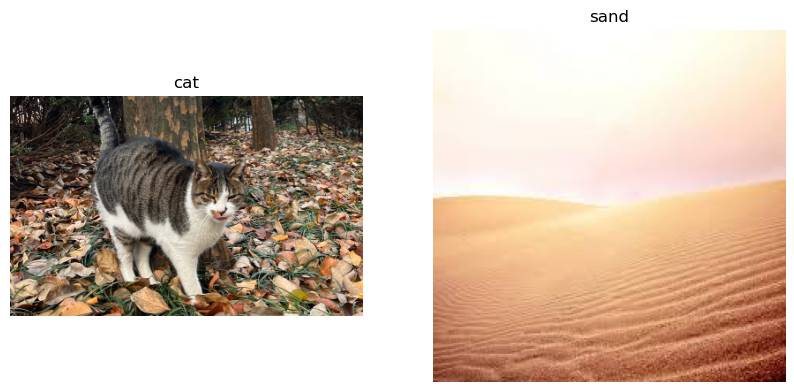

In [12]:
# ============================================================
# 이미지 불러오기 - work 폴더 경로 지정
# ============================================================
import cv2
import matplotlib.pyplot as plt

# ⭐ 'work/' 붙이기!
cat_img_path = "work/cat.png"       # /home/jovyan/work/cat.png
sand_img_path = "work/sand.jpg"     # /home/jovyan/work/sand.jpg

# 이미지 읽기
cat_img = cv2.imread(cat_img_path)
sand_img = cv2.imread(sand_img_path)

# 파일 읽기 성공 여부 확인
print('✅ cat 이미지:', cat_img.shape if cat_img is not None else '❌ 못 찾음')
print('✅ sand 이미지:', sand_img.shape if sand_img is not None else '❌ 못 찾음')

# BGR → RGB 변환 (matplotlib 출력용)
cat_img = cv2.cvtColor(cat_img, cv2.COLOR_BGR2RGB)
sand_img = cv2.cvtColor(sand_img, cv2.COLOR_BGR2RGB)

# 두 이미지 나란히 출력
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(cat_img)
plt.title('cat')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(sand_img)
plt.title('sand')
plt.axis('off')

plt.show()

In [46]:
model = deeplabv3_resnet101(pretrained=True).eval()

transform = T.Compose([
    T.ToPILImage(),
    T.Resize((520, 520)),  # 모델 입력 크기
    T.ToTensor(),
])

input_tensor = transform(cat_img).unsqueeze(0)

with torch.no_grad():
    output = model(input_tensor)["out"][0]
    output_predictions = output.argmax(0).byte().cpu().numpy()

print(f"추론 마스크 크기 (Before Resize): {output_predictions.shape}")

/opt/conda/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/opt/conda/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DeepLabV3_ResNet101_Weights.COCO_WITH_VOC_LABELS_V1`. You can also use `weights=DeepLabV3_ResNet101_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


추론 마스크 크기 (Before Resize): (520, 520)


In [47]:
unique_classes = np.unique(output_predictions_resized)
print(f"예측된 클래스 ID: {unique_classes}")

예측된 클래스 ID: [0 8]


In [15]:
# ============================================================
# 추론 결과를 원본 이미지 크기로 리사이즈
# ============================================================
# 왜 필요한가?
#  - 모델은 520x520으로 예측 (고정 크기)
#  - 원본 이미지는 다른 크기일 수 있음 (예: 400x600)
#  - 마스크를 원본 이미지에 덧씌우려면 크기가 같아야 함!

# 원본 고양이 이미지 크기 확인
original_height, original_width = cat_img.shape[:2]
print(f'원본 이미지 크기: {original_width} x {original_height}')

# 마스크를 원본 크기로 리사이즈
# ⭐ INTER_NEAREST: 클래스 값(정수)은 보간하면 안 됨! 가장 가까운 값 그대로 사용
output_predictions_resized = cv2.resize(
    output_predictions,                  # 520x520 마스크
    (original_width, original_height),   # 원본 크기 (가로, 세로)
    interpolation=cv2.INTER_NEAREST      # 보간 방식 (정수 유지)
)

print(f'리사이즈된 마스크 크기: {output_predictions_resized.shape}')

# 예측된 클래스 종류 확인
unique_classes = np.unique(output_predictions_resized)
print(f'예측된 클래스 ID: {unique_classes}')

원본 이미지 크기: 400 x 250
리사이즈된 마스크 크기: (250, 400)
예측된 클래스 ID: [0 8]


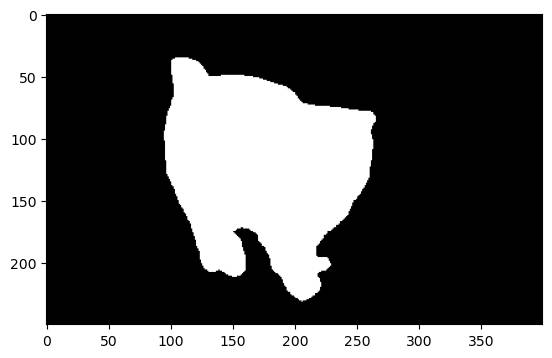

In [16]:
target_class_id = unique_classes[-1]

seg_map = (output_predictions_resized == target_class_id)
img_mask = seg_map.astype(np.uint8) * 255

plt.imshow(img_mask, cmap='gray')
plt.show()

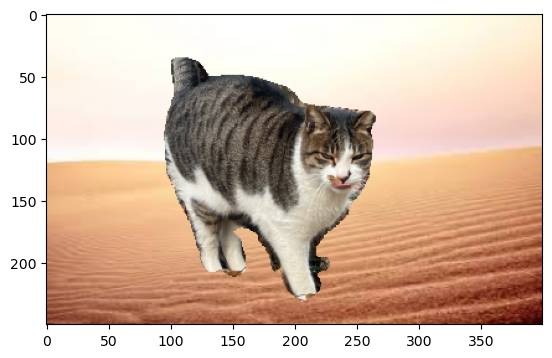

In [17]:
# 배경을 고양이 이미지 크기에 맞춤
sand_img_resized = cv2.resize(sand_img, (cat_img.shape[1], cat_img.shape[0]))

# 고양이 부분만 남기고 배경 적용
img_mask_color = cv2.cvtColor(img_mask, cv2.COLOR_GRAY2BGR)  # 3채널 변환
result_img = np.where(img_mask_color == 255, cat_img, sand_img_resized)  # 마스크 기반 합성

plt.imshow(result_img)
plt.show()

# 이게 머지? 너무 이상한데?
## 고양이 크기 줄이기 + 위치 정하기
문제: 고양이가 너무 커서 사막을 가득 채움   
해결: 고양이를 작게 리사이즈하고 사막 위에 배치

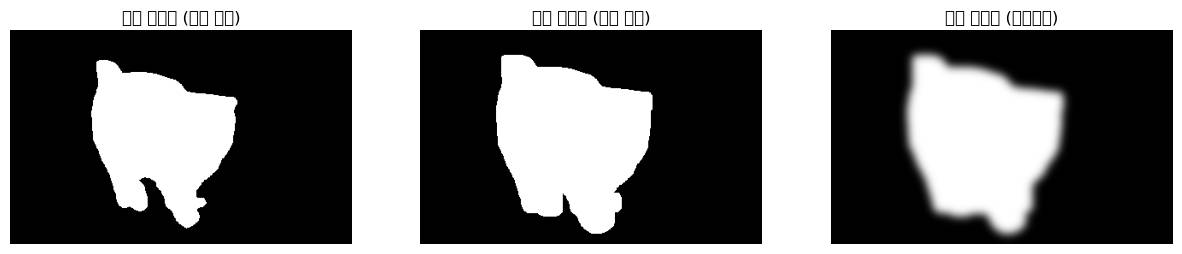

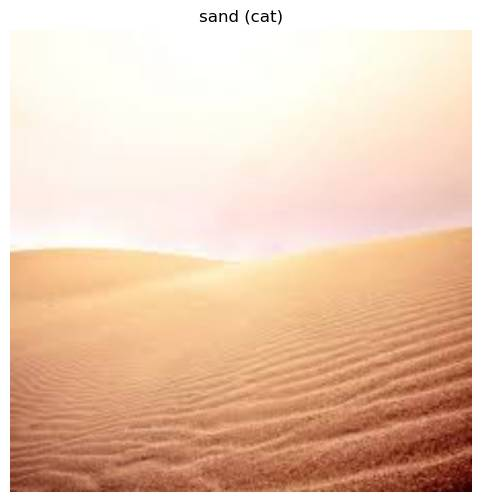

In [34]:


# 셀 1: 마스크 품질 개선 (꼬리 포함 + 경계 부드럽게)
# 원리:
#  - dilation(팽창): 마스크를 사방으로 늘림 → 놓친 꼬리 영역 포함
#  - morphology CLOSE: 마스크 내부의 작은 구멍 메우기
#  - GaussianBlur: 경계 부드럽게

# 1. 원본 마스크 가져오기 (셀 초기에 만든 것)
mask_original = img_mask.copy()

# 2. 팽창(Dilation): 마스크 영역을 늘려서 꼬리 놓친 부분 보완
# 커널 크기 = 얼마나 늘릴지
kernel = np.ones((7, 7), np.uint8)    # ⭐ 7x7 커널로 팽창
mask_dilated = cv2.dilate(mask_original, kernel, iterations=2)    # 2번 반복

# 3. CLOSE 연산: 내부 구멍 메우기 (팽창 후 침식)
mask_closed = cv2.morphologyEx(mask_dilated, cv2.MORPH_CLOSE, 
                                np.ones((15, 15), np.uint8))

# 4. 강한 블러로 경계 부드럽게
mask_final = cv2.GaussianBlur(mask_closed, (31, 31), 0)

# 마스크 개선 과정 비교
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(mask_original, cmap='gray')
axes[0].set_title('원본 마스크 (꼬리 잘림)')
axes[0].axis('off')

axes[1].imshow(mask_dilated, cmap='gray')
axes[1].set_title('팽창 마스크 (꼬리 보완)')
axes[1].axis('off')

axes[2].imshow(mask_final, cmap='gray')
axes[2].set_title('최종 마스크 (부드러움)')
axes[2].axis('off')
plt.show()
plt.figure(figsize=(10, 6))
plt.imshow(background)
plt.title('sand (cat)')
plt.axis('off')
plt.show()

## 고양이 마스크 경계 부드럽게 만들기
문제: 경계선이 계단 모양처럼 거침   
해결: 마스크에 블러 처리 -> 부드러운 그라데이션

배경 크기: (600, 600, 3)
고양이 크기: (200, 320, 3)


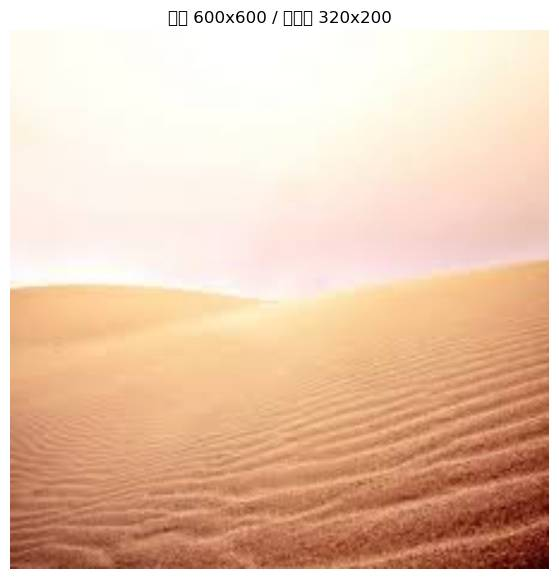

In [35]:


# 셀 2: 배경을 줄이고 고양이를 크게
# 이전: 배경 800 x N, 고양이 60% → 고양이가 작아 보임
# 이번: 배경 600 x N, 고양이 80% → 고양이가 자연스러운 크기

# 1. 배경을 더 작게 (이전 800 → 600)
bg_width = 600    # ⭐ 이전보다 작게!
bg_height = int(sand_img.shape[0] * (bg_width / sand_img.shape[1]))
background = cv2.resize(sand_img, (bg_width, bg_height))

# 2. 고양이는 더 크게 (이전 0.6 → 0.8)
scale = 0.8    # ⭐ 이전보다 크게!
cat_resized = cv2.resize(
    cat_img,
    (int(cat_img.shape[1] * scale), int(cat_img.shape[0] * scale))
)

# 개선된 마스크도 같은 비율로 축소
mask_resized = cv2.resize(
    mask_final,    # ⭐ 셀 1에서 만든 개선된 마스크!
    (int(mask_final.shape[1] * scale), int(mask_final.shape[0] * scale))
)

print(f'배경 크기: {background.shape}')
print(f'고양이 크기: {cat_resized.shape}')

# 3. 위치 계산
cat_h, cat_w = cat_resized.shape[:2]
offset_x = (bg_width - cat_w) // 2
offset_y = bg_height - cat_h - 20    # 바닥에서 20px 위

# 비율이 맞는지 배경 미리 보기
plt.figure(figsize=(10, 7))
plt.imshow(background)
plt.title(f'배경 {bg_width}x{bg_height} / 고양이 {cat_w}x{cat_h}')
plt.axis('off')
plt.show()

## 고양이 색감을 사막 배경에 어울리게 조정
문제: 배경은 석양 -> 색감 안 맞음   
해결: 고양이에 살짝 따뜻한 오렌지 톤 추가

In [36]:
# 셀 3: 색감을 사막에 어울리게 (약하게)
# 이전엔 너무 강해서 고양이가 노란빛이 강했음 → 약하게 조정

cat_adjusted = cat_resized.astype(np.float32)
cat_adjusted[:, :, 0] *= 1.08    # R 8% 증가 (이전 15% → 8%)
cat_adjusted[:, :, 1] *= 1.03    # G 3% 증가
cat_adjusted[:, :, 2] *= 0.92    # B 8% 감소 (이전 15% → 8%)
cat_adjusted = np.clip(cat_adjusted, 0, 255).astype(np.uint8)
print('✅ 색감 조정 완료')

✅ 색감 조정 완료


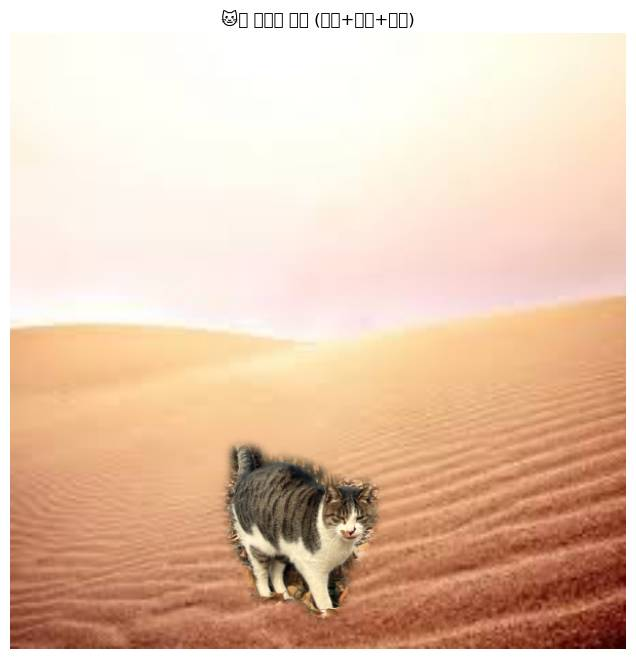

In [37]:

# 셀 4: 배경 + 개선된 마스크 + 고양이 합성

# 1. 알파값(0~1 정규화, 3채널 확장)
alpha = mask_resized.astype(np.float32) / 255.0
alpha_3ch = np.stack([alpha, alpha, alpha], axis=2)

# 2. 결과 = 배경 복사본
result = background.copy()

# 3. 고양이가 들어갈 영역 잘라내기
roi = result[offset_y : offset_y + cat_h,
             offset_x : offset_x + cat_w].astype(np.float32)

# 4. 알파 블렌딩
blended = (cat_adjusted.astype(np.float32) * alpha_3ch +
           roi * (1 - alpha_3ch))

# 5. 결과 배경에 다시 넣기
result[offset_y : offset_y + cat_h,
       offset_x : offset_x + cat_w] = blended.astype(np.uint8)

# 6. 출력
plt.figure(figsize=(10, 8))
plt.imshow(result)
plt.title('🐱🏜️ 개선된 합성 (꼬리+경계+크기)')
plt.axis('off')
plt.show()

# 와 이거 스트레스네

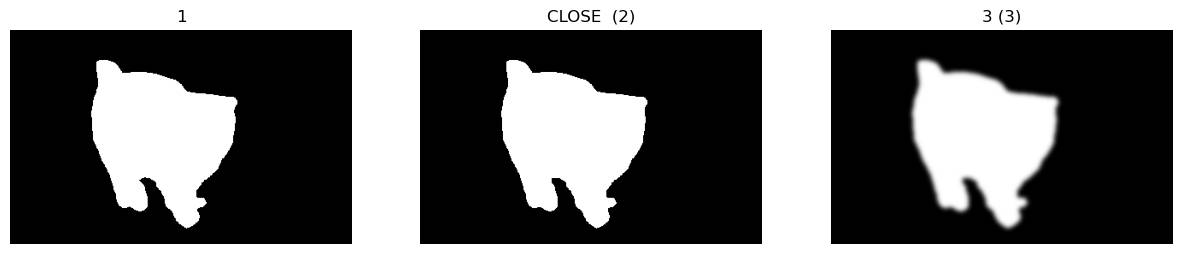

In [49]:
# 셀 1: 마스크 개선 - 팽창 없이 부드럽게만
# 이전 문제: dilation으로 낙엽까지 포함됨
# 해결: 팽창 없이, CLOSE + 블러만 사용

# 1. 원본 마스크
mask_original = img_mask.copy()

# 2. CLOSE 연산만 (내부 구멍 메우기, 경계 확장 없음)
kernel = np.ones((5, 5), np.uint8)
mask_closed = cv2.morphologyEx(mask_original, cv2.MORPH_CLOSE, kernel)

# 3. 블러로 경계만 부드럽게
mask_final = cv2.GaussianBlur(mask_closed, (15, 15), 0)

# 비교해서 보기
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(mask_original, cmap='gray')
axes[0].set_title('1')
axes[0].axis('off')

axes[1].imshow(mask_closed, cmap='gray')
axes[1].set_title('CLOSE  (2)')
axes[1].axis('off')

axes[2].imshow(mask_final, cmap='gray')
axes[2].set_title('3 (3)')
axes[2].axis('off')
plt.show()

In [39]:
# 셀 2: 배경 + 고양이 크기 조정
bg_width = 600
bg_height = int(sand_img.shape[0] * (bg_width / sand_img.shape[1]))
background = cv2.resize(sand_img, (bg_width, bg_height))

scale = 0.8
cat_resized = cv2.resize(
    cat_img,
    (int(cat_img.shape[1] * scale), int(cat_img.shape[0] * scale))
)
mask_resized = cv2.resize(
    mask_final,
    (int(mask_final.shape[1] * scale), int(mask_final.shape[0] * scale))
)

cat_h, cat_w = cat_resized.shape[:2]
offset_x = (bg_width - cat_w) // 2
offset_y = bg_height - cat_h - 20

print(f'배경: {background.shape}')
print(f'고양이: {cat_resized.shape}')

배경: (600, 600, 3)
고양이: (200, 320, 3)


In [40]:
# 셀 3: 색감 살짝 조정
cat_adjusted = cat_resized.astype(np.float32)
cat_adjusted[:, :, 0] *= 1.08
cat_adjusted[:, :, 1] *= 1.03
cat_adjusted[:, :, 2] *= 0.92
cat_adjusted = np.clip(cat_adjusted, 0, 255).astype(np.uint8)

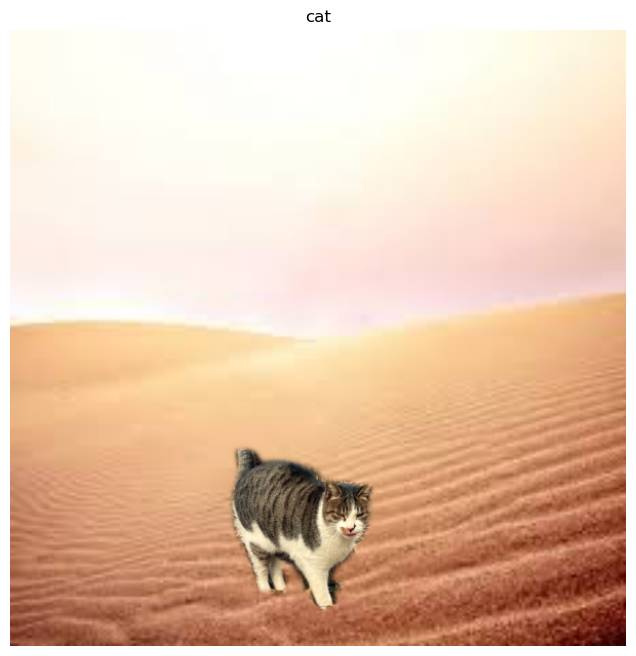

In [48]:
# 셀 4: 최종 합성
alpha = mask_resized.astype(np.float32) / 255.0
alpha_3ch = np.stack([alpha, alpha, alpha], axis=2)

result = background.copy()
roi = result[offset_y : offset_y + cat_h,
             offset_x : offset_x + cat_w].astype(np.float32)
blended = (cat_adjusted.astype(np.float32) * alpha_3ch +
           roi * (1 - alpha_3ch))
result[offset_y : offset_y + cat_h,
       offset_x : offset_x + cat_w] = blended.astype(np.uint8)

plt.figure(figsize=(10, 8))
plt.imshow(result)
plt.title('cat')
plt.axis('off')
plt.show()

# 클로드 왈
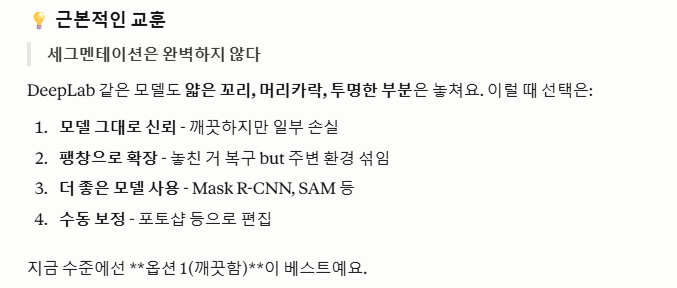

# Grab Cut이 더 좋다고?

Cat image: (250, 400, 3)
Desert image (original): (225, 225, 3)
Cat image (resized): (125, 200, 3)
Desert image (resized): (250, 600, 3)
Running GrabCut... (5-10 seconds)
Mask done!
Cat size: 125 x 200
Desert size: 250 x 600
✅ Cat position: (200, 95)
ROI shape: (125, 200, 3)
Cat shape: (125, 200, 3)
Alpha shape: (125, 200, 3)


/tmp/ipykernel_86/4197049797.py:120: UserWarning: Glyph 127964 (\N{DESERT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/opt/conda/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 127964 (\N{DESERT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


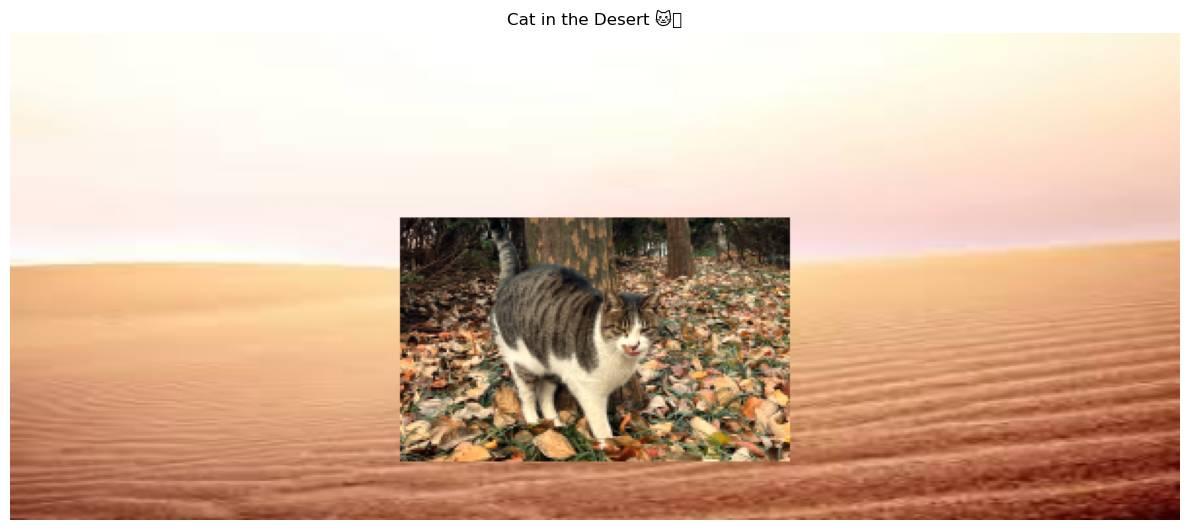

In [54]:
# ============================================================
# Cat to Desert (Fixed: Resize background properly)
# ============================================================
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

# --- 1. File paths ---
home_dir = os.getenv('HOME')
cat_original_path = os.path.join(home_dir, 'work/cat.png')
desert_bg_path = os.path.join(home_dir, 'work/sand.jpg')

# --- 2. Load images ---
cat_bgr = cv2.imread(cat_original_path)
cat_rgb = cv2.cvtColor(cat_bgr, cv2.COLOR_BGR2RGB)

desert_bgr = cv2.imread(desert_bg_path)
desert_rgb = cv2.cvtColor(desert_bgr, cv2.COLOR_BGR2RGB)

print(f'Cat image: {cat_rgb.shape}')        # (h, w, 3)
print(f'Desert image (original): {desert_rgb.shape}')

# ⭐ FIX 1: Resize cat smaller first
cat_scale = 0.5    # Make cat 50% size (adjust: 0.3 smaller, 0.7 bigger)
cat_rgb = cv2.resize(cat_rgb, 
                     (int(cat_rgb.shape[1] * cat_scale), 
                      int(cat_rgb.shape[0] * cat_scale)))
print(f'Cat image (resized): {cat_rgb.shape}')

# ⭐ FIX 2: Resize desert to be BIGGER than cat
# Desert should be ~2.5x bigger than cat
target_bg_width = cat_rgb.shape[1] * 3       # 3x cat width
target_bg_height = cat_rgb.shape[0] * 2      # 2x cat height
desert_rgb = cv2.resize(desert_rgb, (target_bg_width, target_bg_height))
print(f'Desert image (resized): {desert_rgb.shape}')

# Add padding to prevent tail cut-off
h, w = cat_rgb.shape[:2]
temp_pad = 50
cat_padded = cv2.copyMakeBorder(cat_rgb, temp_pad, temp_pad, temp_pad, temp_pad,
                                 cv2.BORDER_CONSTANT, value=[255, 255, 255])
h_p, w_p = cat_padded.shape[:2]

# --- 3. GrabCut ---
print('Running GrabCut... (5-10 seconds)')
mask_grabcut = np.zeros((h_p, w_p), np.uint8)
bgdModel = np.zeros((1, 65), np.float64)
fgdModel = np.zeros((1, 65), np.float64)

rect = (temp_pad, temp_pad, w, h)

cv2.grabCut(cv2.cvtColor(cat_padded, cv2.COLOR_RGB2BGR),
            mask_grabcut, rect, bgdModel, fgdModel, 5, cv2.GC_INIT_WITH_RECT)

mask_cat_padded = np.where((mask_grabcut == 2) | (mask_grabcut == 0), 0, 1).astype('uint8') * 255
mask_cat = mask_cat_padded[temp_pad:temp_pad+h, temp_pad:temp_pad+w]
print('Mask done!')

# --- 4. Feather edges ---
feather_amount = 5
alpha_mask = cv2.GaussianBlur(mask_cat,
                               (feather_amount*2+1, feather_amount*2+1),
                               feather_amount) / 255.0
alpha_3ch = np.stack([alpha_mask, alpha_mask, alpha_mask], axis=2)

# --- 5. Color grading ---
adjusted_cat_rgb = (cat_rgb.astype(np.float32) * [1.1, 1.05, 0.95]).clip(0, 255).astype(np.uint8)

# --- 6. Position + shadow ---
h_c, w_c = adjusted_cat_rgb.shape[:2]
h_d, w_d = desert_rgb.shape[:2]

print(f'Cat size: {h_c} x {w_c}')
print(f'Desert size: {h_d} x {w_d}')

# ⭐ FIX 3: Safe position calculation
# Make sure offset_y and offset_x are >= 0
offset_y = max(0, h_d - h_c - 30)           # Bottom with 30px margin
offset_x = max(0, (w_d - w_c) // 2)          # Center horizontally

# Safety check
if offset_y + h_c > h_d or offset_x + w_c > w_d:
    print(f'⚠️ Cat does not fit in background!')
    print(f'   Needed: {offset_x + w_c} x {offset_y + h_c}')
    print(f'   Available: {w_d} x {h_d}')
else:
    print(f'✅ Cat position: ({offset_x}, {offset_y})')

result = desert_rgb.copy()

# Shadow
shadow_width, shadow_height = w_c // 2, 15
shadow_color = (10, 5, 2)
shadow_mask = np.zeros((h_d, w_d, 3), dtype=np.uint8)
cv2.ellipse(shadow_mask,
            (offset_x + w_c // 2, offset_y + h_c - 5),
            (shadow_width, shadow_height),
            0, 0, 360, shadow_color, -1)
shadow_mask_blurred = cv2.GaussianBlur(shadow_mask, (51, 51), 15)
result = cv2.addWeighted(result, 1.0, shadow_mask_blurred, -0.6, 0)

# --- 7. Alpha blending ---
roi = result[offset_y:offset_y + h_c, offset_x:offset_x + w_c].astype(np.float32)
cat_float = adjusted_cat_rgb.astype(np.float32)

# ⭐ Debug: Check shapes before blending
print(f'ROI shape: {roi.shape}')
print(f'Cat shape: {cat_float.shape}')
print(f'Alpha shape: {alpha_3ch.shape}')

blended = (cat_float * alpha_3ch + roi * (1 - alpha_3ch)).astype(np.uint8)
result[offset_y:offset_y + h_c, offset_x:offset_x + w_c] = blended

# --- 8. Display ---
plt.figure(figsize=(12, 10))
plt.imshow(result)
plt.title('Cat in the Desert 🐱🏜️')
plt.axis('off')
plt.tight_layout()
plt.show()

# 차원이 다르다는 SAM 을 사용해보자! 

In [55]:
# SAM 설치 및 사용
!pip install segment-anything

from segment_anything import sam_model_registry, SamPredictor
import urllib.request

# 모델 가중치 다운로드 (한 번만)
url = "https://dl.fbaipublicfiles.com/segment_anything/sam_vit_b_01ec64.pth"
urllib.request.urlretrieve(url, "sam_vit_b.pth")

# 모델 로드
sam = sam_model_registry["vit_b"](checkpoint="sam_vit_b.pth")
predictor = SamPredictor(sam)

# 고양이 이미지 설정
predictor.set_image(cat_rgb)

# 고양이 몸통 중앙 점 찍기 (x, y)
input_point = np.array([[cat_rgb.shape[1]//2, cat_rgb.shape[0]//2]])
input_label = np.array([1])   # 1 = 전경

# 예측
masks, scores, _ = predictor.predict(
    point_coords=input_point,
    point_labels=input_label,
    multimask_output=True,
)

# 가장 점수 높은 마스크 사용
best_mask = masks[np.argmax(scores)]
img_mask = (best_mask * 255).astype(np.uint8)

마스크 shape: (125, 200)
마스크 값 범위: 0 ~ 255
고양이 영역 픽셀 수: 4098
점수들: [0.7323191  0.90507185 0.72691715]
선택된 마스크 점수: 0.905


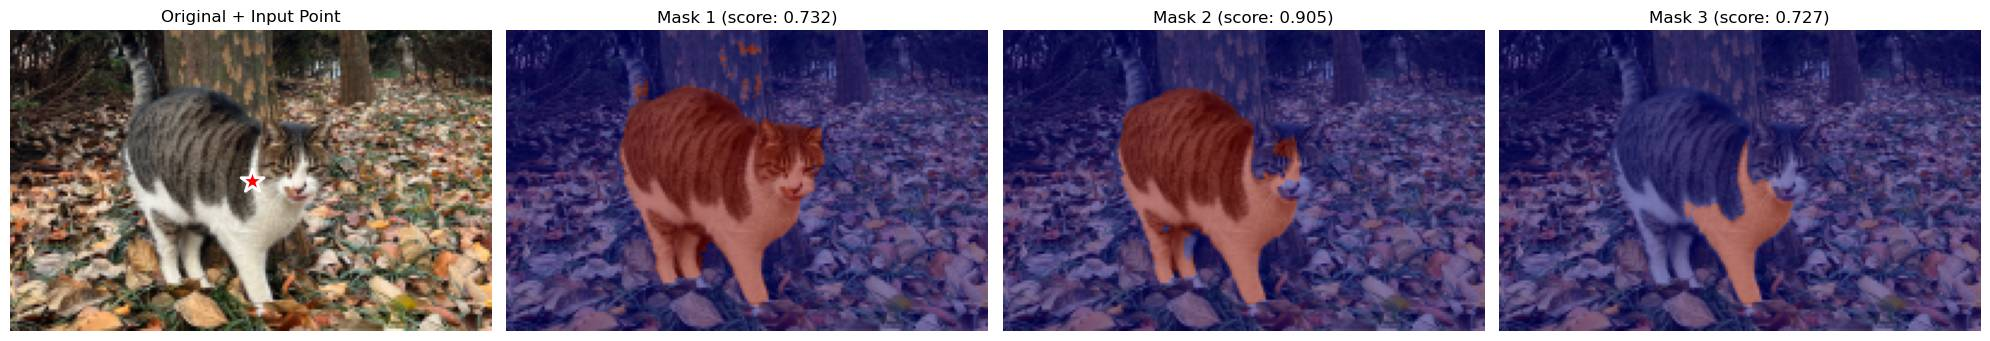

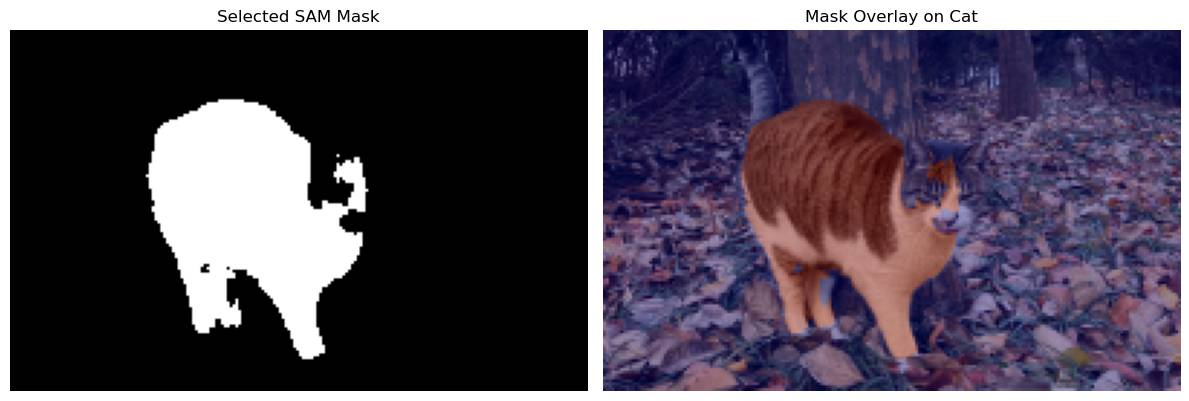

In [56]:
# ============================================================
# SAM이 만든 마스크 확인
# ============================================================
import matplotlib.pyplot as plt
import numpy as np

# 1. 마스크 정보 출력
print(f'마스크 shape: {img_mask.shape}')
print(f'마스크 값 범위: {img_mask.min()} ~ {img_mask.max()}')
print(f'고양이 영역 픽셀 수: {np.sum(img_mask > 0)}')
print(f'점수들: {scores}')
print(f'선택된 마스크 점수: {scores[np.argmax(scores)]:.3f}')

# 2. 3개 마스크 후보 모두 비교
h, w = cat_rgb.shape[:2]
input_point = np.array([[w // 2, h // 2]])

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

# 원본 + 점 표시
axes[0].imshow(cat_rgb)
axes[0].scatter(input_point[:, 0], input_point[:, 1],
                c='red', s=300, marker='*', 
                edgecolors='white', linewidths=2)
axes[0].set_title('Original + Input Point')
axes[0].axis('off')

# 마스크 3개 후보 (고양이 위에 오버레이)
for i, (mask, score) in enumerate(zip(masks, scores)):
    axes[i+1].imshow(cat_rgb)
    axes[i+1].imshow(mask, alpha=0.5, cmap='jet')
    axes[i+1].set_title(f'Mask {i+1} (score: {score:.3f})')
    axes[i+1].axis('off')

plt.tight_layout()
plt.show()

# 3. 선택된 마스크만 크게 보기
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(img_mask, cmap='gray')
axes[0].set_title('Selected SAM Mask')
axes[0].axis('off')

axes[1].imshow(cat_rgb)
axes[1].imshow(img_mask, alpha=0.4, cmap='jet')
axes[1].set_title('Mask Overlay on Cat')
axes[1].axis('off')

plt.tight_layout()
plt.show()

원본 이미지 크기: (250, 400, 3)
🔍 원본 이미지 분석 중...
✅ 분석 완료
전경 점: 5개
배경 점: 3개
🎯 SAM 예측 중...
✅ 선택된 마스크 점수: 0.966
마스크 shape: (250, 400)


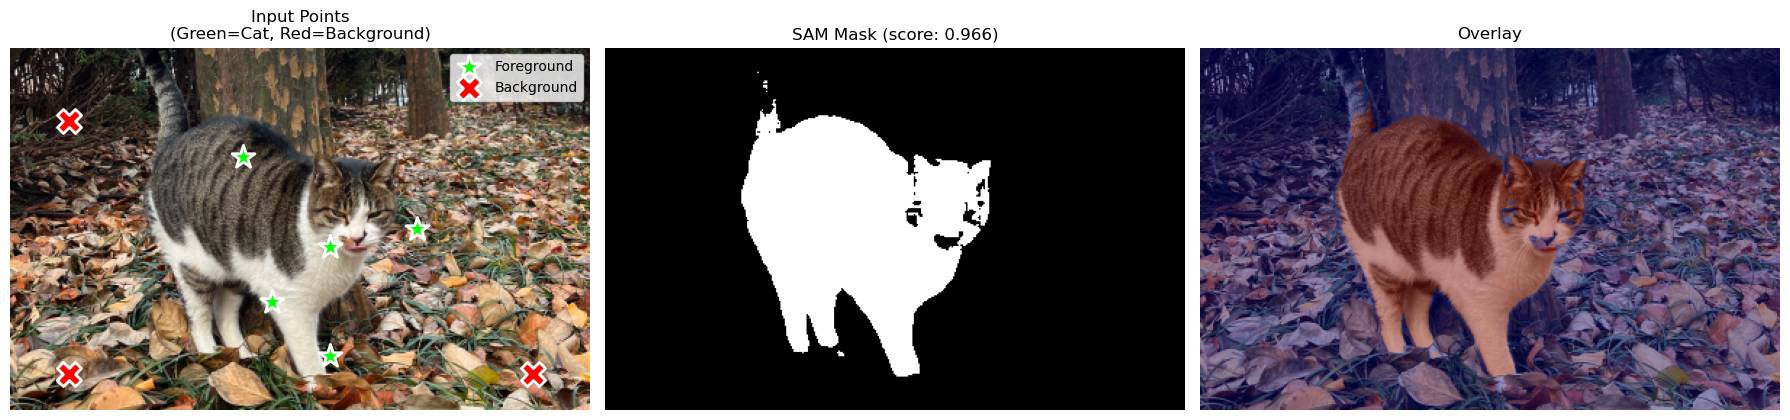

In [57]:
# ============================================================
# SAM 재시도: 원본 이미지 + 여러 점
# ============================================================
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

# 1. 원본 고양이 이미지 다시 불러오기 (리사이즈 없이!)
home_dir = os.getenv('HOME')
cat_path = os.path.join(home_dir, 'work/cat.png')
cat_bgr_original = cv2.imread(cat_path)
cat_rgb_original = cv2.cvtColor(cat_bgr_original, cv2.COLOR_BGR2RGB)

print(f'원본 이미지 크기: {cat_rgb_original.shape}')

# 2. SAM에 원본 이미지 입력
print('🔍 원본 이미지 분석 중...')
predictor.set_image(cat_rgb_original)
print('✅ 분석 완료')

# 3. ⭐ 점 여러 개 찍기 (몸통 + 얼굴 + 꼬리 + 발)
h, w = cat_rgb_original.shape[:2]

# 고양이 주요 부위에 전경 점 찍기
input_point = np.array([
    [w * 0.55, h * 0.55],    # 몸통 중앙
    [w * 0.70, h * 0.50],    # 얼굴
    [w * 0.40, h * 0.30],    # 꼬리 (위쪽)
    [w * 0.55, h * 0.85],    # 앞발
    [w * 0.45, h * 0.70],    # 몸통 뒤쪽
]).astype(int)

# 배경에도 점 찍기 (낙엽은 고양이 아님!)
bg_points = np.array([
    [w * 0.1, h * 0.9],      # 왼쪽 아래 낙엽
    [w * 0.9, h * 0.9],      # 오른쪽 아래 낙엽
    [w * 0.1, h * 0.2],      # 왼쪽 위 (나무)
]).astype(int)

# 전경 + 배경 점 합치기
all_points = np.vstack([input_point, bg_points])
all_labels = np.array([1]*len(input_point) + [0]*len(bg_points))  # 1=전경, 0=배경

print(f'전경 점: {len(input_point)}개')
print(f'배경 점: {len(bg_points)}개')

# 4. 예측
print('🎯 SAM 예측 중...')
masks, scores, _ = predictor.predict(
    point_coords=all_points,
    point_labels=all_labels,
    multimask_output=True,
)

# 5. 최고 점수 마스크 선택
best_idx = np.argmax(scores)
best_mask = masks[best_idx]
img_mask = (best_mask * 255).astype(np.uint8)

print(f'✅ 선택된 마스크 점수: {scores[best_idx]:.3f}')
print(f'마스크 shape: {img_mask.shape}')

# 6. 시각화 (점 위치 + 마스크)
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# 원본 + 점들
axes[0].imshow(cat_rgb_original)
# 전경 점 (녹색 별)
axes[0].scatter(input_point[:, 0], input_point[:, 1],
                c='lime', s=300, marker='*', 
                edgecolors='white', linewidths=2, label='Foreground')
# 배경 점 (빨간 X)
axes[0].scatter(bg_points[:, 0], bg_points[:, 1],
                c='red', s=300, marker='X',
                edgecolors='white', linewidths=2, label='Background')
axes[0].set_title('Input Points\n(Green=Cat, Red=Background)')
axes[0].legend(loc='upper right')
axes[0].axis('off')

# 마스크만
axes[1].imshow(img_mask, cmap='gray')
axes[1].set_title(f'SAM Mask (score: {scores[best_idx]:.3f})')
axes[1].axis('off')

# 오버레이
axes[2].imshow(cat_rgb_original)
axes[2].imshow(img_mask, alpha=0.4, cmap='jet')
axes[2].set_title('Overlay')
axes[2].axis('off')

plt.tight_layout()
plt.show()

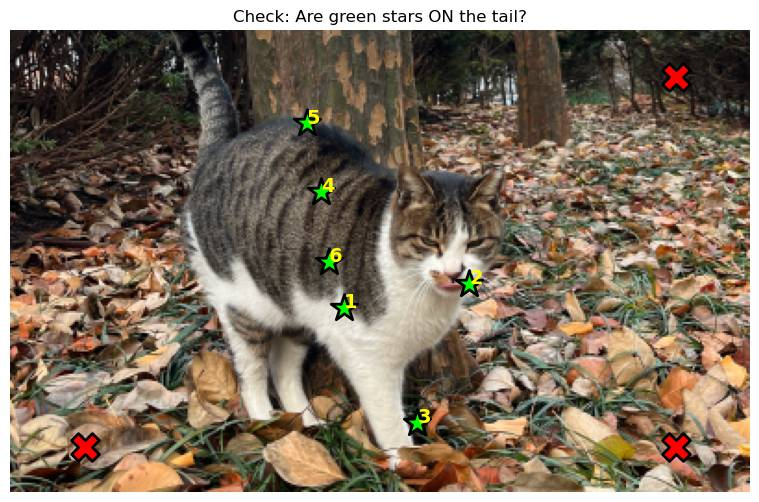

In [61]:
# ============================================================
# 꼬리까지 포함되도록 점 추가
# ============================================================
h, w = cat_rgb_original.shape[:2]

# ⭐ 꼬리 위치에 점 2개 추가 (꼬리가 길기 때문에)
input_point = np.array([
    [w * 0.45, h * 0.60],    # 몸통 중앙
    [w * 0.62, h * 0.55],    # 얼굴
    [w * 0.55, h * 0.85],    # 앞발
    
    # ⭐ 꼬리 위치! (여러 점으로 꼬리 전체 커버)
    [w * 0.42, h * 0.35],    # 꼬리 중간
    [w * 0.40, h * 0.20],    # 꼬리 위쪽
    [w * 0.43, h * 0.50],    # 꼬리 아랫부분 (몸통 연결)
]).astype(int)

bg_points = np.array([
    [w * 0.1, h * 0.9],      # 왼쪽 아래 낙엽
    [w * 0.9, h * 0.9],      # 오른쪽 아래 낙엽
    [w * 0.9, h * 0.1],      # 오른쪽 위 (나무)
]).astype(int)

all_points = np.vstack([input_point, bg_points])
all_labels = np.array([1]*len(input_point) + [0]*len(bg_points))

# 점 위치 먼저 확인 (꼬리 위에 점이 있는지!)
plt.figure(figsize=(10, 6))
plt.imshow(cat_rgb_original)
plt.scatter(input_point[:, 0], input_point[:, 1],
            c='lime', s=400, marker='*', 
            edgecolors='black', linewidths=2)
plt.scatter(bg_points[:, 0], bg_points[:, 1],
            c='red', s=400, marker='X',
            edgecolors='black', linewidths=2)

# 꼬리 영역 확인용 번호 표시
for i, pt in enumerate(input_point):
    plt.annotate(f'{i+1}', pt, color='yellow', fontsize=14, fontweight='bold')

plt.title('Check: Are green stars ON the tail?')
plt.axis('off')
plt.show()

# 왜 꼬리를 못찾지?
## 어떤게 나무인지 어떤게 꼬리인지 구분을 못함. 이거를 구분짓게 만들어야 하는데 어렵네.
### 좌표를 이용해서 해야하나? 아니면 간단한 방법이 없나?

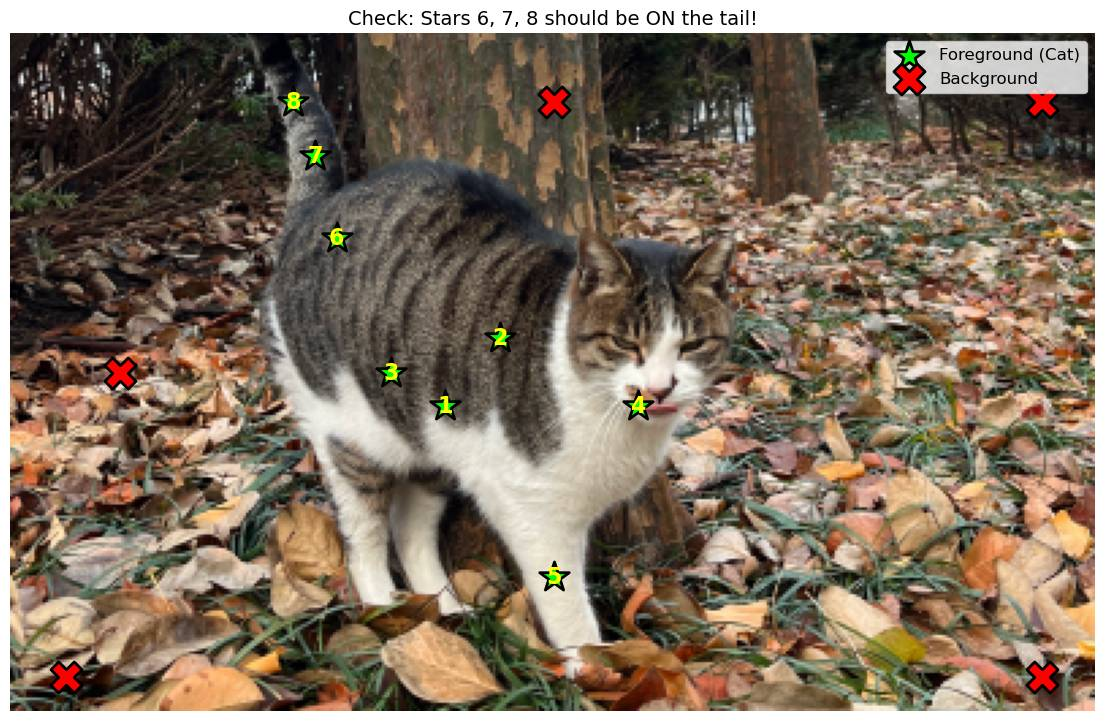

In [66]:
# ============================================================
# 꼬리 위치 정확히 지정!
# ============================================================
h, w = cat_rgb_original.shape[:2]

# ⭐ 고양이 전체 영역에 점 찍기
input_point = np.array([
    # --- 몸통 ---
    [w * 0.40, h * 0.55],    # 1. 몸통 중앙 (흰 배)
    [w * 0.45, h * 0.45],    # 2. 등 위쪽
    [w * 0.35, h * 0.50],    # 3. 몸통 왼쪽
    
    # --- 얼굴 ---
    [w * 0.58, h * 0.55],    # 4. 얼굴
    
    # --- 앞발 ---
    [w * 0.50, h * 0.80],    # 5. 앞발 (몸통 아래)
    
    # --- 🎯 꼬리 (실제 위치!) ---
    [w * 0.30, h * 0.30],    # 6. 꼬리 뿌리 (등 왼쪽)
    [w * 0.28, h * 0.18],    # 7. 꼬리 중간
    [w * 0.26, h * 0.10],    # 8. 꼬리 끝
]).astype(int)

# 배경 점 (고양이가 아닌 곳)
bg_points = np.array([
    [w * 0.05, h * 0.95],    # 왼쪽 아래 낙엽
    [w * 0.95, h * 0.95],    # 오른쪽 아래 낙엽
    [w * 0.95, h * 0.10],    # 오른쪽 위 (나무/숲)
    [w * 0.50, h * 0.10],    # 위쪽 중앙 (나무)
    [w * 0.10, h * 0.50],    # 왼쪽 중간 (낙엽)
]).astype(int)

all_points = np.vstack([input_point, bg_points])
all_labels = np.array([1]*len(input_point) + [0]*len(bg_points))

# 점 위치 먼저 확인!
plt.figure(figsize=(14, 9))
plt.imshow(cat_rgb_original)
plt.scatter(input_point[:, 0], input_point[:, 1],
            c='lime', s=500, marker='*', 
            edgecolors='black', linewidths=2, label='Foreground (Cat)')
plt.scatter(bg_points[:, 0], bg_points[:, 1],
            c='red', s=500, marker='X',
            edgecolors='black', linewidths=2, label='Background')

# 번호 표시
for i, pt in enumerate(input_point):
    plt.annotate(f'{i+1}', pt, color='yellow', fontsize=16, 
                 fontweight='bold', ha='center', va='center')

plt.title('Check: Stars 6, 7, 8 should be ON the tail!', fontsize=14)
plt.legend(fontsize=12, loc='upper right')
plt.axis('off')
plt.show()

🎯 SAM 예측 중...
✅ 점수: 0.965


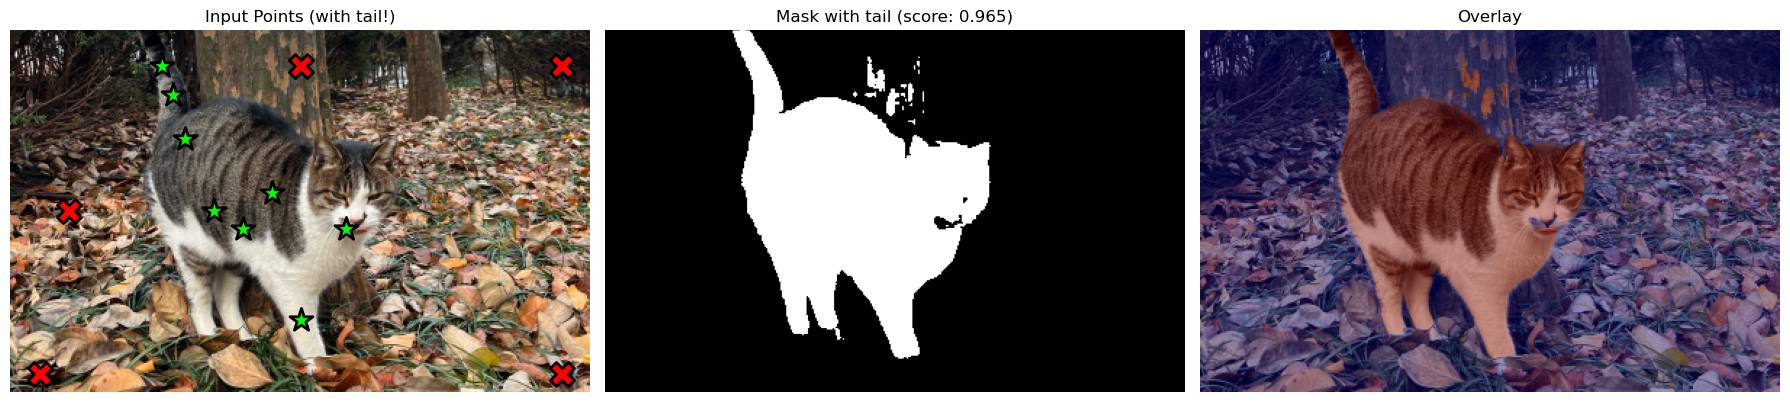

In [67]:
# ============================================================
# SAM 예측 (꼬리 포함)
# ============================================================
print('🎯 SAM 예측 중...')
masks, scores, _ = predictor.predict(
    point_coords=all_points,
    point_labels=all_labels,
    multimask_output=True,
)

best_idx = np.argmax(scores)
best_mask = masks[best_idx]
img_mask = (best_mask * 255).astype(np.uint8)

print(f'✅ 점수: {scores[best_idx]:.3f}')

# 결과 시각화
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(cat_rgb_original)
axes[0].scatter(input_point[:, 0], input_point[:, 1],
                c='lime', s=300, marker='*', edgecolors='black', linewidths=2)
axes[0].scatter(bg_points[:, 0], bg_points[:, 1],
                c='red', s=300, marker='X', edgecolors='black', linewidths=2)
axes[0].set_title('Input Points (with tail!)')
axes[0].axis('off')

axes[1].imshow(img_mask, cmap='gray')
axes[1].set_title(f'Mask with tail (score: {scores[best_idx]:.3f})')
axes[1].axis('off')

axes[2].imshow(cat_rgb_original)
axes[2].imshow(img_mask, alpha=0.4, cmap='jet')
axes[2].set_title('Overlay')
axes[2].axis('off')

plt.tight_layout()
plt.show()

Desert: (225, 225, 3)
Cat: (250, 400, 3)
Mask: (250, 400)
Resized cat: (125, 200, 3)
Background: (250, 600, 3)


/tmp/ipykernel_86/1856217781.py:72: UserWarning: Glyph 127964 (\N{DESERT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


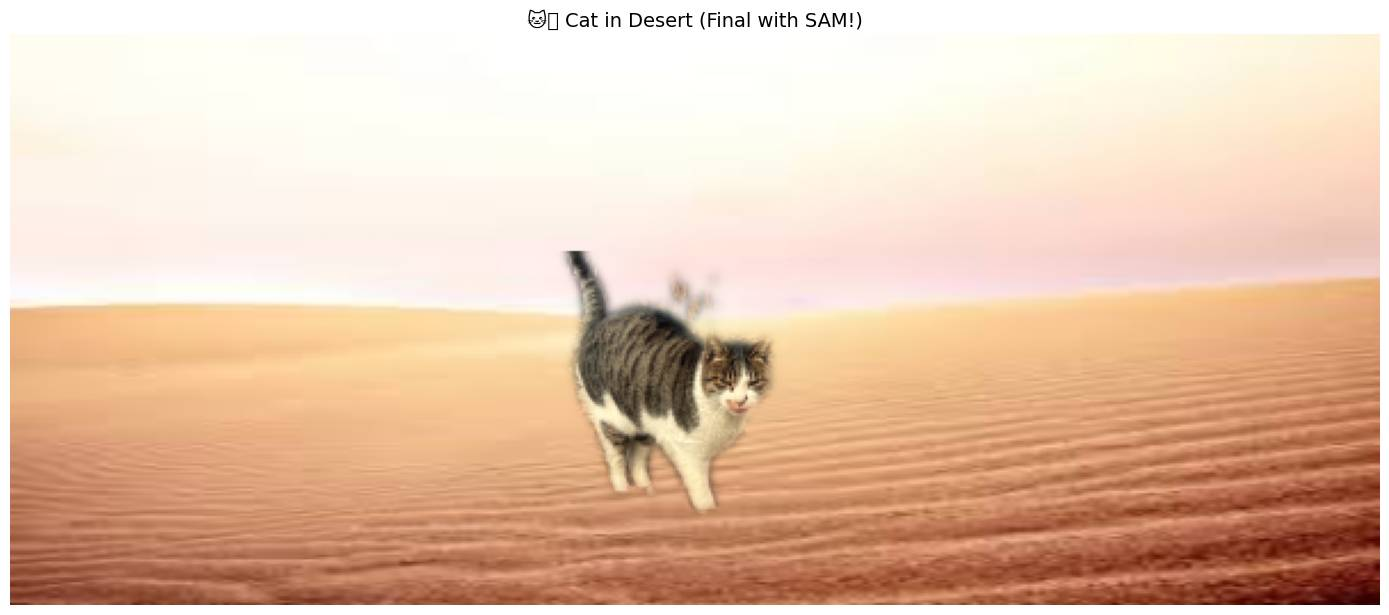

In [68]:
# ============================================================
# SAM 마스크로 최종 사막 합성!
# ============================================================
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

# 1. 사막 이미지 불러오기
home_dir = os.getenv('HOME')
sand_path = os.path.join(home_dir, 'work/sand.jpg')
sand_bgr = cv2.imread(sand_path)
sand_rgb = cv2.cvtColor(sand_bgr, cv2.COLOR_BGR2RGB)

print(f'Desert: {sand_rgb.shape}')
print(f'Cat: {cat_rgb_original.shape}')
print(f'Mask: {img_mask.shape}')

# 2. 고양이와 마스크 크기 조정 (사막에 자연스럽게 들어갈 크기)
cat_scale = 0.5    # 고양이 50% 크기로
new_w = int(cat_rgb_original.shape[1] * cat_scale)
new_h = int(cat_rgb_original.shape[0] * cat_scale)

cat_resized = cv2.resize(cat_rgb_original, (new_w, new_h))
mask_resized = cv2.resize(img_mask, (new_w, new_h))

print(f'Resized cat: {cat_resized.shape}')

# 3. 사막 배경 크기 조정 (고양이보다 크게)
bg_width = new_w * 3
bg_height = new_h * 2
background = cv2.resize(sand_rgb, (bg_width, bg_height))

print(f'Background: {background.shape}')

# 4. 경계선 부드럽게 (페더링)
mask_feathered = cv2.GaussianBlur(mask_resized, (11, 11), 0)
alpha = mask_feathered.astype(np.float32) / 255.0
alpha_3ch = np.stack([alpha, alpha, alpha], axis=2)

# 5. 색감 조정 (사막 따뜻한 톤)
cat_adjusted = (cat_resized.astype(np.float32) * [1.1, 1.05, 0.92]).clip(0, 255).astype(np.uint8)

# 6. 고양이 위치 (중앙 하단)
h_c, w_c = cat_adjusted.shape[:2]
h_d, w_d = background.shape[:2]

offset_y = h_d - h_c - 30
offset_x = (w_d - w_c) // 2

# 7. 그림자 추가
result = background.copy()
shadow_layer = np.zeros_like(result)
cv2.ellipse(shadow_layer,
            (offset_x + w_c // 2, offset_y + h_c - 5),
            (w_c // 3, 12),
            0, 0, 360, (20, 10, 5), -1)
shadow_blurred = cv2.GaussianBlur(shadow_layer, (41, 41), 12)
result = cv2.addWeighted(result, 1.0, shadow_blurred, -0.5, 0)

# 8. 알파 블렌딩으로 합성
roi = result[offset_y:offset_y+h_c, offset_x:offset_x+w_c].astype(np.float32)
cat_float = cat_adjusted.astype(np.float32)
blended = (cat_float * alpha_3ch + roi * (1 - alpha_3ch)).astype(np.uint8)
result[offset_y:offset_y+h_c, offset_x:offset_x+w_c] = blended

# 9. 최종 출력
plt.figure(figsize=(14, 10))
plt.imshow(result)
plt.title('🐱🏜️ Cat in Desert (Final with SAM!)', fontsize=14)
plt.axis('off')
plt.tight_layout()
plt.show()

## 오오....좋아. 
### 등에있는 점박이들도 없애보자

발견된 덩어리 수: 6개 (배경 제외)
  덩어리 1: 크기 20105 픽셀
  덩어리 2: 크기 499 픽셀
  덩어리 3: 크기 24 픽셀
  덩어리 4: 크기 7 픽셀
  덩어리 5: 크기 2 픽셀
  덩어리 6: 크기 9 픽셀
✅ 가장 큰 덩어리: 1번 (고양이)


/tmp/ipykernel_86/2158568251.py:50: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/opt/conda/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


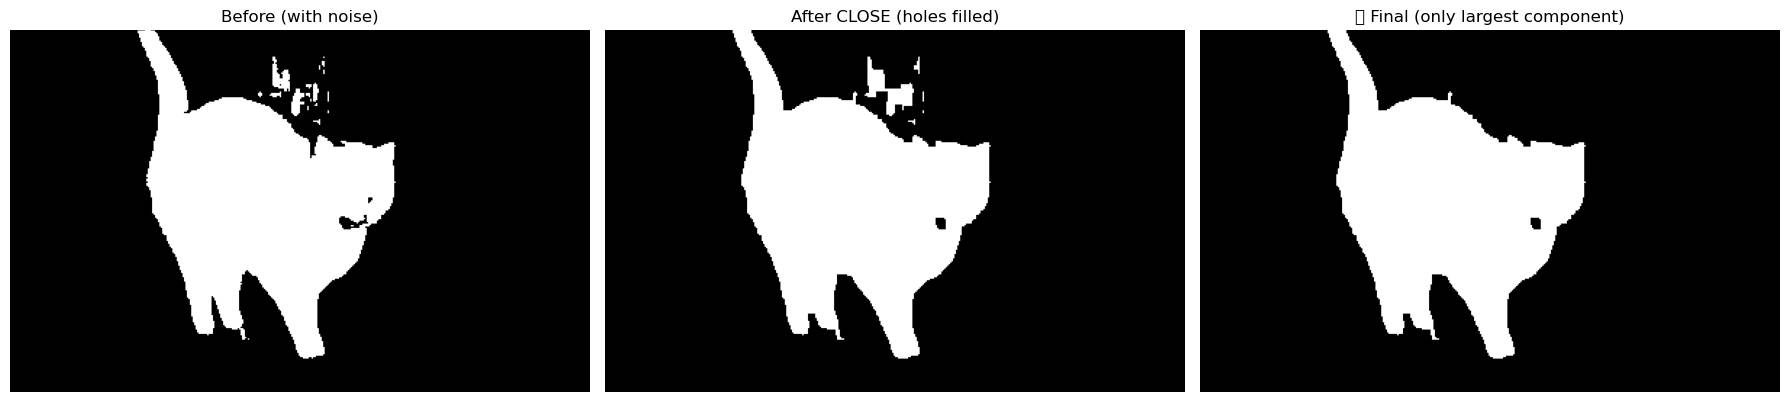

✅ 노이즈 제거 완료! img_mask 업데이트됨


In [69]:
# ============================================================
# 마스크 노이즈 제거 (꼬리 주변 검은 점 제거)
# ============================================================
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1. 원본 SAM 마스크 백업
mask_before = img_mask.copy()

# 2. 작은 구멍 메우기 (CLOSE 연산)
kernel = np.ones((5, 5), np.uint8)
mask_closed = cv2.morphologyEx(img_mask, cv2.MORPH_CLOSE, kernel)

# 3. 가장 큰 연결 요소만 남기기 (작은 노이즈 제거)
# connectedComponentsWithStats: 이미지를 "연결된 덩어리"로 분리
num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(mask_closed)

print(f'발견된 덩어리 수: {num_labels - 1}개 (배경 제외)')
for i in range(1, num_labels):
    area = stats[i, cv2.CC_STAT_AREA]
    print(f'  덩어리 {i}: 크기 {area} 픽셀')

# 가장 큰 덩어리(=고양이) 찾기
# stats[0]은 배경이니까 제외
if num_labels > 1:
    largest_label = 1 + np.argmax(stats[1:, cv2.CC_STAT_AREA])
    print(f'✅ 가장 큰 덩어리: {largest_label}번 (고양이)')
    
    # 가장 큰 덩어리만 흰색, 나머지는 검은색
    mask_clean = np.where(labels == largest_label, 255, 0).astype(np.uint8)
else:
    mask_clean = mask_closed

# 4. 결과 비교
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(mask_before, cmap='gray')
axes[0].set_title('Before (with noise)')
axes[0].axis('off')

axes[1].imshow(mask_closed, cmap='gray')
axes[1].set_title('After CLOSE (holes filled)')
axes[1].axis('off')

axes[2].imshow(mask_clean, cmap='gray')
axes[2].set_title('✅ Final (only largest component)')
axes[2].axis('off')

plt.tight_layout()
plt.show()

# 5. 깨끗해진 마스크로 교체
img_mask = mask_clean
print('✅ 노이즈 제거 완료! img_mask 업데이트됨')

/tmp/ipykernel_86/119812051.py:58: UserWarning: Glyph 127964 (\N{DESERT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


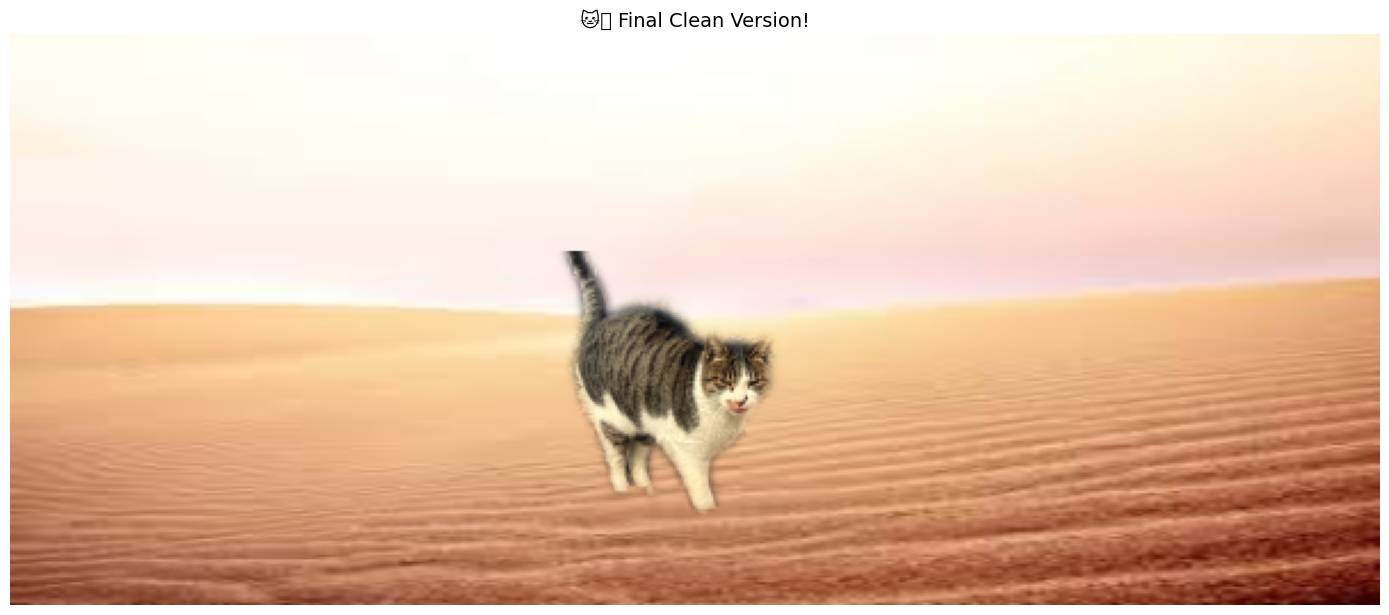

In [70]:
# ============================================================
# 깨끗한 마스크로 최종 합성!
# ============================================================
import os

home_dir = os.getenv('HOME')
sand_path = os.path.join(home_dir, 'work/sand.jpg')
sand_bgr = cv2.imread(sand_path)
sand_rgb = cv2.cvtColor(sand_bgr, cv2.COLOR_BGR2RGB)

# 1. 크기 조정
cat_scale = 0.5
new_w = int(cat_rgb_original.shape[1] * cat_scale)
new_h = int(cat_rgb_original.shape[0] * cat_scale)

cat_resized = cv2.resize(cat_rgb_original, (new_w, new_h))
mask_resized = cv2.resize(img_mask, (new_w, new_h))    # ⭐ 깨끗한 마스크 사용!

# 2. 배경
bg_width = new_w * 3
bg_height = new_h * 2
background = cv2.resize(sand_rgb, (bg_width, bg_height))

# 3. 페더링
mask_feathered = cv2.GaussianBlur(mask_resized, (11, 11), 0)
alpha = mask_feathered.astype(np.float32) / 255.0
alpha_3ch = np.stack([alpha, alpha, alpha], axis=2)

# 4. 색감 조정
cat_adjusted = (cat_resized.astype(np.float32) * [1.1, 1.05, 0.92]).clip(0, 255).astype(np.uint8)

# 5. 위치 + 그림자
h_c, w_c = cat_adjusted.shape[:2]
h_d, w_d = background.shape[:2]
offset_y = h_d - h_c - 30
offset_x = (w_d - w_c) // 2

result = background.copy()
shadow_layer = np.zeros_like(result)
cv2.ellipse(shadow_layer,
            (offset_x + w_c // 2, offset_y + h_c - 5),
            (w_c // 3, 12),
            0, 0, 360, (20, 10, 5), -1)
shadow_blurred = cv2.GaussianBlur(shadow_layer, (41, 41), 12)
result = cv2.addWeighted(result, 1.0, shadow_blurred, -0.5, 0)

# 6. 합성
roi = result[offset_y:offset_y+h_c, offset_x:offset_x+w_c].astype(np.float32)
cat_float = cat_adjusted.astype(np.float32)
blended = (cat_float * alpha_3ch + roi * (1 - alpha_3ch)).astype(np.uint8)
result[offset_y:offset_y+h_c, offset_x:offset_x+w_c] = blended

# 7. 출력
plt.figure(figsize=(14, 10))
plt.imshow(result)
plt.title('🐱🏜️ Final Clean Version!', fontsize=14)
plt.axis('off')
plt.tight_layout()
plt.show()

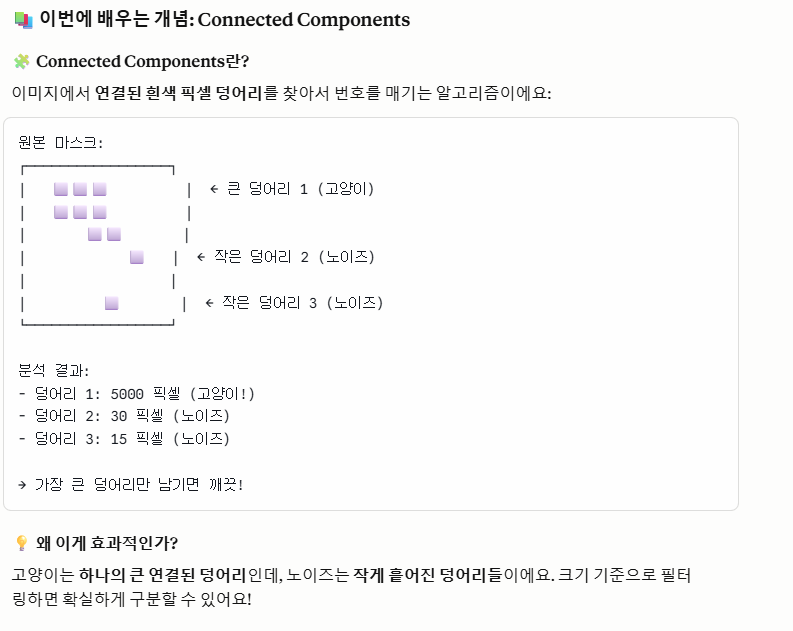

# 2. 수지를 DeepLab으로 아웃포커싱 해보자
### mediapipe 설치하고 실행했지만 GPU와 쥬피터에 버전과호환이 맞지 않아 포기

In [2]:
# DeepLab 모델 살아있는지 확인
if 'model' in dir():
    print('✅ model 변수 있음, 바로 사용 가능')
else:
    print('❌ model 변수 없음, 다시 로드 필요')

❌ model 변수 없음, 다시 로드 필요


In [3]:
# ============================================================
# DeepLab 모델 로드
# ============================================================
import torch
import torchvision.transforms as T
from torchvision.models.segmentation import deeplabv3_resnet101
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

print('🔄 DeepLab 모델 로드 중...')
model = deeplabv3_resnet101(pretrained=True).eval()

transform = T.Compose([
    T.ToPILImage(),
    T.Resize((520, 520)),
    T.ToTensor(),
])

home_dir = os.getenv('HOME')
print('✅ DeepLab 준비 완료!')

🔄 DeepLab 모델 로드 중...


/opt/conda/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/opt/conda/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DeepLabV3_ResNet101_Weights.COCO_WITH_VOC_LABELS_V1`. You can also use `weights=DeepLabV3_ResNet101_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


✅ DeepLab 준비 완료!


이미지 크기: (360, 640, 3)


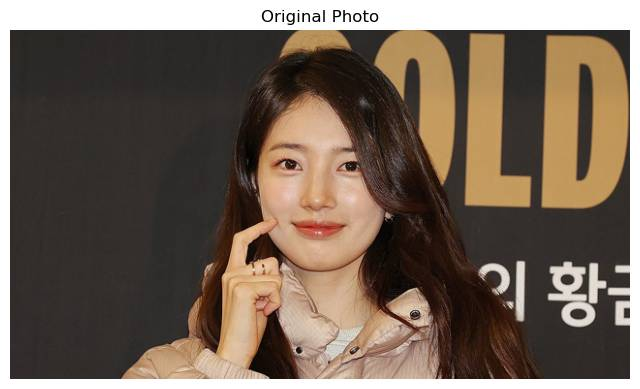

In [4]:
# ============================================================
# 인물 사진 로드
# ============================================================
person_path = os.path.join(home_dir, 'work/suji.jpg')
person_bgr = cv2.imread(person_path)
person_rgb = cv2.cvtColor(person_bgr, cv2.COLOR_BGR2RGB)

print(f'이미지 크기: {person_rgb.shape}')

plt.figure(figsize=(8, 6))
plt.imshow(person_rgb)
plt.title('Original Photo')
plt.axis('off')
plt.show()

🔍 세그멘테이션 중...
검출된 클래스: [ 0 15]
(15=사람, 8=고양이, 12=강아지, 0=배경)
✅ 마스크 생성 완료: (360, 640)


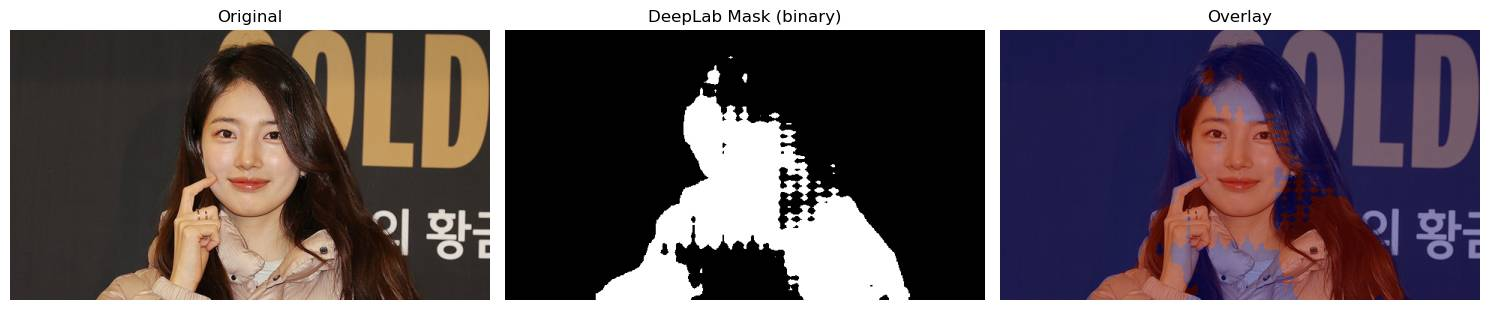

In [6]:
# ============================================================
# DeepLab으로 인물 세그멘테이션
# ============================================================
# Pascal VOC 클래스 중:
#  - 15 = person (사람)
#  - 8 = cat (고양이)
#  - 12 = dog (강아지)

# 1. 이미지를 모델 입력 형식으로 변환
input_tensor = transform(person_rgb).unsqueeze(0)

# 2. 세그멘테이션 실행
print('🔍 세그멘테이션 중...')
with torch.no_grad():
    output = model(input_tensor)["out"][0]
    predictions = output.argmax(0).byte().cpu().numpy()

# 3. 원본 크기로 리사이즈
h, w = person_rgb.shape[:2]
predictions_resized = cv2.resize(
    predictions, (w, h), 
    interpolation=cv2.INTER_NEAREST
)

# 4. 검출된 클래스 확인
unique_classes = np.unique(predictions_resized)
print(f'검출된 클래스: {unique_classes}')
print(f'(15=사람, 8=고양이, 12=강아지, 0=배경)')

# 5. 사람 클래스(15)만 마스크로
PERSON_CLASS = 15
mask_binary = np.where(predictions_resized == PERSON_CLASS, 255, 0).astype(np.uint8)

print(f'✅ 마스크 생성 완료: {mask_binary.shape}')

# 6. 마스크 시각화
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(person_rgb)
axes[0].set_title('Original')
axes[0].axis('off')

axes[1].imshow(mask_binary, cmap='gray')
axes[1].set_title('DeepLab Mask (binary)')
axes[1].axis('off')

axes[2].imshow(person_rgb)
axes[2].imshow(mask_binary, alpha=0.4, cmap='jet')
axes[2].set_title('Overlay')
axes[2].axis('off')

plt.tight_layout()
plt.show()

/tmp/ipykernel_1066/855565401.py:40: UserWarning: Glyph 10024 (\N{SPARKLES}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/opt/conda/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 10024 (\N{SPARKLES}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


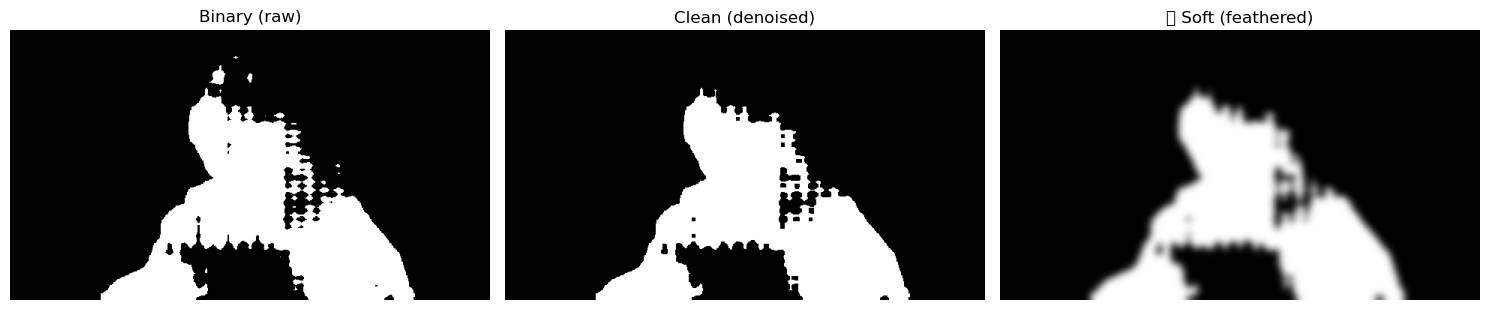

In [7]:
# ============================================================
# 이진 마스크를 부드럽게 (MediaPipe의 soft mask 효과)
# ============================================================
# DeepLab은 0/255 이진 마스크
# 블러 처리로 경계를 부드럽게 만들면 아웃포커싱에 최적!

# 1. 노이즈 제거 (작은 구멍 메우기)
kernel = np.ones((5, 5), np.uint8)
mask_closed = cv2.morphologyEx(mask_binary, cv2.MORPH_CLOSE, kernel)

# 2. 가장 큰 덩어리(인물)만 남기기 (노이즈 제거)
num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(mask_closed)
if num_labels > 1:
    largest_label = 1 + np.argmax(stats[1:, cv2.CC_STAT_AREA])
    mask_clean = np.where(labels == largest_label, 255, 0).astype(np.uint8)
else:
    mask_clean = mask_closed

# 3. 가우시안 블러로 경계 부드럽게 (← 핵심!)
mask_soft = cv2.GaussianBlur(mask_clean, (31, 31), 0)

# 4. 0~1 범위로 정규화 (알파값)
mask_soft_norm = mask_soft.astype(np.float32) / 255.0

# 5. 비교 시각화
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(mask_binary, cmap='gray')
axes[0].set_title('Binary (raw)')
axes[0].axis('off')

axes[1].imshow(mask_clean, cmap='gray')
axes[1].set_title('Clean (denoised)')
axes[1].axis('off')

axes[2].imshow(mask_soft, cmap='gray')
axes[2].set_title('✨ Soft (feathered)')
axes[2].axis('off')

plt.tight_layout()
plt.show()

/tmp/ipykernel_1066/1460022986.py:30: UserWarning: Glyph 10024 (\N{SPARKLES}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


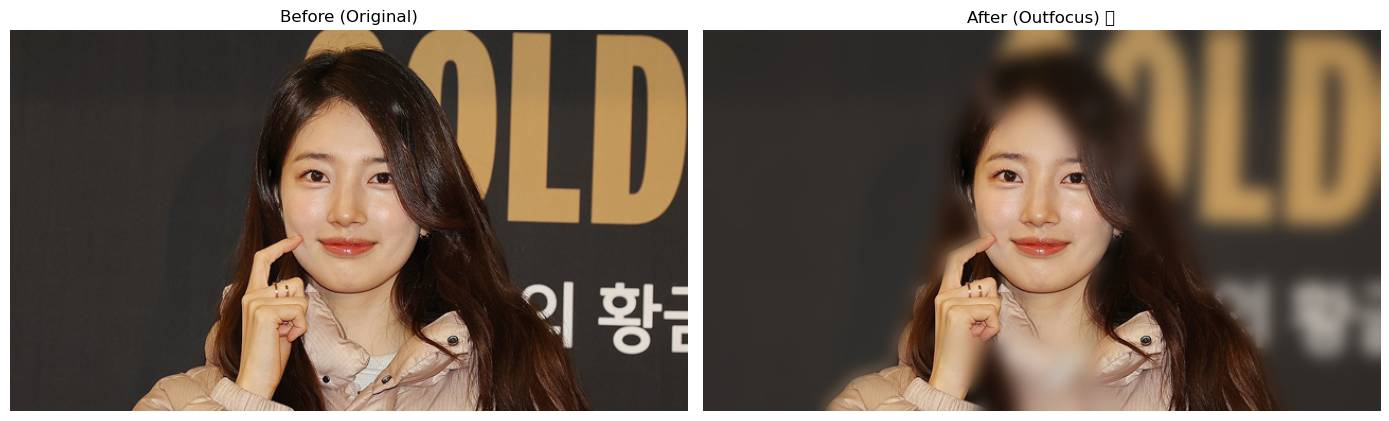

In [8]:
# ============================================================
# 아웃포커싱 효과 적용!
# ============================================================

# 1. 배경 전체 블러 처리
blur_strength = 51    # ⭐ 흐림 강도 (홀수): 21 약함, 51 보통, 99 강함
background_blurred = cv2.GaussianBlur(person_rgb, (blur_strength, blur_strength), 0)

# 2. 3채널 마스크로 확장 (RGB 각각에 적용하기 위해)
mask_3ch = np.stack([mask_soft_norm, mask_soft_norm, mask_soft_norm], axis=2)

# 3. 알파 블렌딩으로 합성
# - 인물 영역 (mask ≈ 1): 원본 선명
# - 배경 영역 (mask ≈ 0): 블러 처리됨
# - 경계 (mask ≈ 0.5): 부드럽게 섞임
result = (person_rgb * mask_3ch + 
          background_blurred * (1 - mask_3ch)).astype(np.uint8)

# 4. Before / After 비교
fig, axes = plt.subplots(1, 2, figsize=(14, 7))

axes[0].imshow(person_rgb)
axes[0].set_title('Before (Original)')
axes[0].axis('off')

axes[1].imshow(result)
axes[1].set_title('After (Outfocus) ✨')
axes[1].axis('off')

plt.tight_layout()
plt.show()

# 피부톤과 비슷한 의상을 구분을 못함. 그래서 다시 SAM 으로 도전

In [10]:
# SAM predictor 변수 확인
if 'predictor' in dir():
    print('✅ predictor 살아있음, 바로 사용 가능')
else:
    print('❌ predictor 없음, SAM 모델 다시 로드 필요')

❌ predictor 없음, SAM 모델 다시 로드 필요


In [12]:
# ============================================================
# SAM 파일 찾기
# ============================================================
import os
import subprocess

home_dir = os.getenv('HOME')

# 방법 1: find 명령어로 전체 검색
print('🔍 sam_vit_b.pth 파일 검색 중...')
result = subprocess.run(
    ['find', home_dir, '-name', 'sam_vit_b*.pth', '-type', 'f'],
    capture_output=True, text=True
)
print('찾은 파일:')
print(result.stdout if result.stdout else '  (없음)')

# 방법 2: home 폴더에 있나?
home_file = os.path.join(home_dir, 'sam_vit_b.pth')
if os.path.exists(home_file):
    print(f'✅ home에 있음: {home_file}')

# 방법 3: 현재 디렉토리
cwd_file = os.path.join(os.getcwd(), 'sam_vit_b.pth')
if os.path.exists(cwd_file):
    print(f'✅ 현재 폴더에 있음: {cwd_file}')

🔍 sam_vit_b.pth 파일 검색 중...
찾은 파일:
/home/jovyan/sam_vit_b.pth

✅ home에 있음: /home/jovyan/sam_vit_b.pth
✅ 현재 폴더에 있음: /home/jovyan/sam_vit_b.pth


In [13]:
# ============================================================
# SAM 로드 (올바른 경로로!)
# ============================================================
from segment_anything import sam_model_registry, SamPredictor
import torch
import os

home_dir = os.getenv('HOME')

# ⭐ 올바른 경로 (work 폴더 아님!)
sam_checkpoint = os.path.join(home_dir, 'sam_vit_b.pth')

# 파일 존재 확인
print(f'경로: {sam_checkpoint}')
print(f'파일 존재: {os.path.exists(sam_checkpoint)}')

# 로드
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f'Device: {device}')

print('🔄 SAM 로드 중...')
sam = sam_model_registry["vit_b"](checkpoint=sam_checkpoint)
sam.to(device=device)
predictor = SamPredictor(sam)
print('✅ SAM 준비 완료!')

경로: /home/jovyan/sam_vit_b.pth
파일 존재: True
Device: cpu
🔄 SAM 로드 중...
✅ SAM 준비 완료!


In [14]:
# ============================================================
# 인물 이미지 등록
# ============================================================
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 이미지 확인
if 'person_rgb' not in dir():
    person_path = os.path.join(home_dir, 'work/suji.jpg')
    person_bgr = cv2.imread(person_path)
    person_rgb = cv2.cvtColor(person_bgr, cv2.COLOR_BGR2RGB)

print('🔍 이미지 분석 중...')
predictor.set_image(person_rgb)
print(f'✅ 완료! 이미지 크기: {person_rgb.shape}')

🔍 이미지 분석 중...
✅ 완료! 이미지 크기: (360, 640, 3)


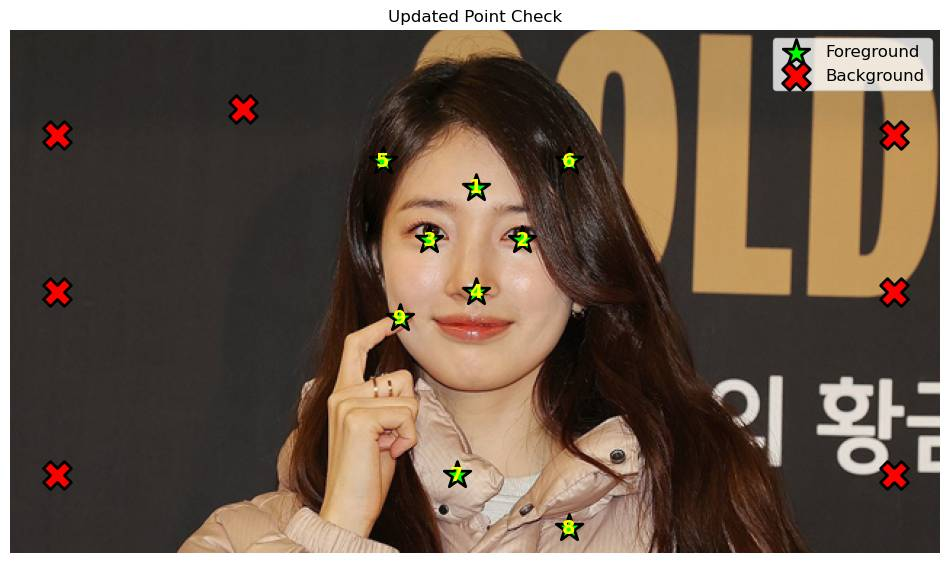

In [24]:
# ============================================================
# 점 위치 재조정 (수지 사진에 맞게)
# ============================================================
h, w = person_rgb.shape[:2]

# 🟢 전경 점 (수지 실제 몸 위치)
input_point = np.array([
    # 얼굴
    [w * 0.50, h * 0.30],    # 1. 얼굴 중앙 (코 위쪽)
    [w * 0.55, h * 0.40],    # 2. 볼 (오른쪽)
    [w * 0.45, h * 0.40],    # 3. 볼 (왼쪽)
    [w * 0.50, h * 0.50],    # 4. 입/턱
    
    # 머리카락 (얼굴 위쪽 + 옆)
    [w * 0.40, h * 0.25],    # 5. 왼쪽 머리카락
    [w * 0.60, h * 0.25],    # 6. 오른쪽 머리카락
    
    # 몸통/옷
    [w * 0.48, h * 0.85],    # 7. 가슴/패딩 점퍼
    [w * 0.60, h * 0.95],    # 8. 옷 아래
    
    # 손
    [w * 0.42, h * 0.55],    # 9. 손 (볼 근처)
]).astype(int)

# 🔴 배경 점 (수지 몸 바깥)
bg_points = np.array([
    [w * 0.05, h * 0.20],    # 왼쪽 위 배경
    [w * 0.95, h * 0.20],    # 오른쪽 위 배경 (GOLD)
    [w * 0.05, h * 0.50],    # 왼쪽 중간 배경
    [w * 0.95, h * 0.50],    # 오른쪽 중간 (GOLD 글자)
    [w * 0.05, h * 0.85],    # 왼쪽 아래 배경
    [w * 0.95, h * 0.85],    # 오른쪽 아래 배경
    [w * 0.25, h * 0.15],    # 왼쪽 위 (GOLD 위)
]).astype(int)

all_points = np.vstack([input_point, bg_points])
all_labels = np.array([1]*len(input_point) + [0]*len(bg_points))

# 점 위치 다시 확인
plt.figure(figsize=(12, 9))
plt.imshow(person_rgb)
plt.scatter(input_point[:, 0], input_point[:, 1],
            c='lime', s=400, marker='*', 
            edgecolors='black', linewidths=2, label='Foreground')
plt.scatter(bg_points[:, 0], bg_points[:, 1],
            c='red', s=400, marker='X',
            edgecolors='black', linewidths=2, label='Background')

for i, pt in enumerate(input_point):
    plt.annotate(f'{i+1}', pt, color='yellow', fontsize=14, 
                 fontweight='bold', ha='center', va='center')

plt.title('Updated Point Check')
plt.legend(fontsize=12, loc='upper right')
plt.axis('off')
plt.show()

🎯 SAM 예측 중...
✅ 점수: 0.988
모든 마스크 점수: [0.98815525 0.97632617 0.9064232 ]


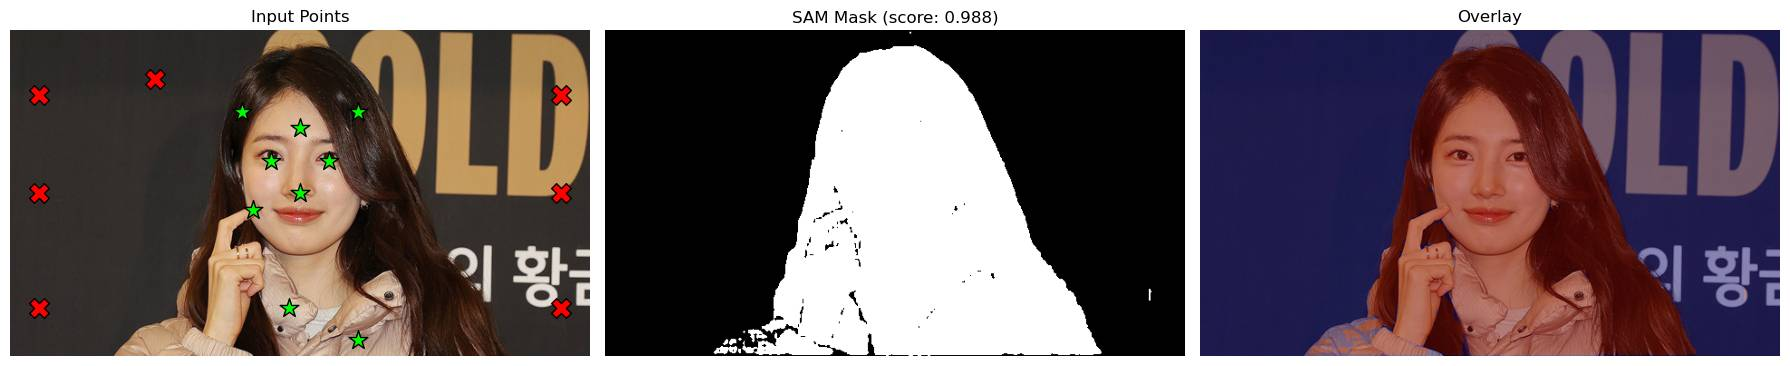

In [25]:
# ============================================================
# SAM 예측 실행
# ============================================================
print('🎯 SAM 예측 중...')
masks, scores, _ = predictor.predict(
    point_coords=all_points,
    point_labels=all_labels,
    multimask_output=True,
)

# 최고 점수 마스크 선택
best_idx = np.argmax(scores)
best_mask = masks[best_idx]
img_mask_sam = (best_mask * 255).astype(np.uint8)

print(f'✅ 점수: {scores[best_idx]:.3f}')
print(f'모든 마스크 점수: {scores}')

# 결과 시각화
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# 원본 + 점
axes[0].imshow(person_rgb)
axes[0].scatter(input_point[:, 0], input_point[:, 1],
                c='lime', s=200, marker='*', edgecolors='black')
axes[0].scatter(bg_points[:, 0], bg_points[:, 1],
                c='red', s=200, marker='X', edgecolors='black')
axes[0].set_title('Input Points')
axes[0].axis('off')

# 마스크
axes[1].imshow(img_mask_sam, cmap='gray')
axes[1].set_title(f'SAM Mask (score: {scores[best_idx]:.3f})')
axes[1].axis('off')

# 오버레이
axes[2].imshow(person_rgb)
axes[2].imshow(img_mask_sam, alpha=0.4, cmap='jet')
axes[2].set_title('Overlay')
axes[2].axis('off')

plt.tight_layout()
plt.show()

/tmp/ipykernel_1066/2374254188.py:40: UserWarning: Glyph 10024 (\N{SPARKLES}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/opt/conda/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 10024 (\N{SPARKLES}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


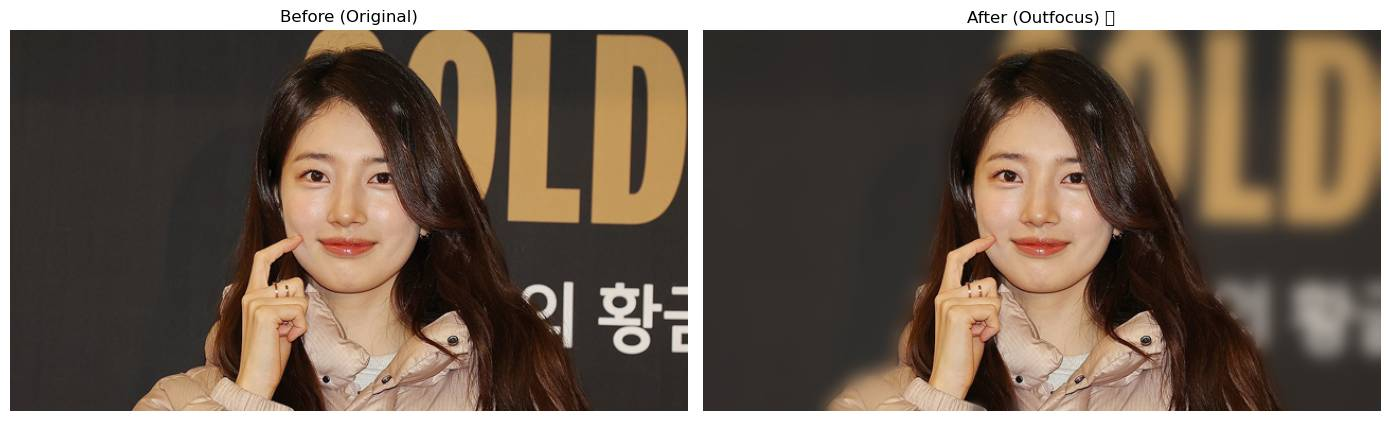

In [26]:
# ============================================================
# 아웃포커싱 적용
# ============================================================

# 1. 마스크 노이즈 제거 (가장 큰 덩어리만)
kernel = np.ones((5, 5), np.uint8)
mask_closed = cv2.morphologyEx(img_mask_sam, cv2.MORPH_CLOSE, kernel)

num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(mask_closed)
if num_labels > 1:
    largest = 1 + np.argmax(stats[1:, cv2.CC_STAT_AREA])
    mask_clean = np.where(labels == largest, 255, 0).astype(np.uint8)
else:
    mask_clean = mask_closed

# 2. 경계 부드럽게 (페더링)
mask_soft = cv2.GaussianBlur(mask_clean, (21, 21), 0)
mask_soft_norm = mask_soft.astype(np.float32) / 255.0

# 3. 배경 블러
blur_strength = 51    # 21 약함, 51 보통, 99 강함
background_blurred = cv2.GaussianBlur(person_rgb, (blur_strength, blur_strength), 0)

# 4. 알파 블렌딩
mask_3ch = np.stack([mask_soft_norm, mask_soft_norm, mask_soft_norm], axis=2)
result = (person_rgb * mask_3ch + 
          background_blurred * (1 - mask_3ch)).astype(np.uint8)

# 5. Before / After 비교
fig, axes = plt.subplots(1, 2, figsize=(14, 7))

axes[0].imshow(person_rgb)
axes[0].set_title('Before (Original)')
axes[0].axis('off')

axes[1].imshow(result)
axes[1].set_title('After (Outfocus) ✨')
axes[1].axis('off')

plt.tight_layout()
plt.show()

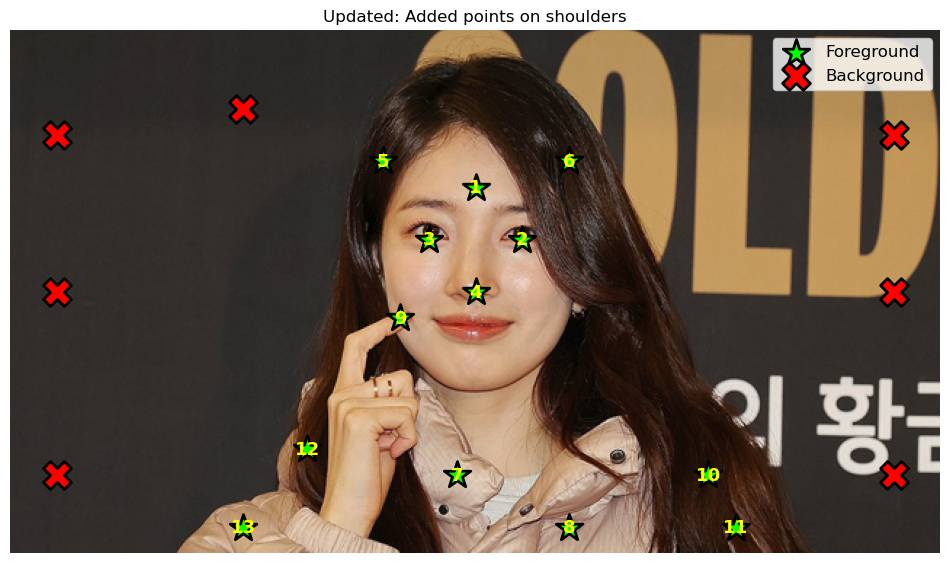

In [35]:
# ============================================================
# 오른쪽 옷/어깨 영역에 점 추가
# ============================================================
h, w = person_rgb.shape[:2]

# 🟢 전경 점 (옷 영역 점 추가!)
input_point = np.array([
    # 얼굴
    [w * 0.50, h * 0.30],    # 1. 이마
    [w * 0.55, h * 0.40],    # 2. 오른쪽 볼/눈
    [w * 0.45, h * 0.40],    # 3. 왼쪽 볼/눈
    [w * 0.50, h * 0.50],    # 4. 코
    
    # 머리카락
    [w * 0.40, h * 0.25],    # 5. 왼쪽 머리카락
    [w * 0.60, h * 0.25],    # 6. 오른쪽 머리카락
    
    # 옷 (원래)
   [w * 0.48, h * 0.85],    # 7. 가슴/패딩 점퍼
    [w * 0.60, h * 0.95],    # 8. 옷 아래
    
    # 손
    [w * 0.42, h * 0.55],    # 9. 손 (볼 근처)
    
    # ⭐ 새로 추가! 어깨 영역
    [w * 0.75, h * 0.85],    # 10. 오른쪽 어깨 ⭐ 추가
    [w * 0.78, h * 0.95],    # 11. 오른쪽 어깨 아래 ⭐ 추가
    [w * 0.32, h * 0.80],    # 12. 왼쪽 어깨 (보강)
    [w * 0.25, h * 0.95],    # 13. 왼쪽 어깨 끝 (긴 머리 때문에)
]).astype(int)

# 🔴 배경 점 (수정 없음)
bg_points = np.array([
    [w * 0.05, h * 0.20],
    [w * 0.95, h * 0.20],
    [w * 0.05, h * 0.50],
    [w * 0.95, h * 0.50],
    [w * 0.05, h * 0.85],
    [w * 0.95, h * 0.85],
    [w * 0.25, h * 0.15],
]).astype(int)

all_points = np.vstack([input_point, bg_points])
all_labels = np.array([1]*len(input_point) + [0]*len(bg_points))

# 점 위치 확인
plt.figure(figsize=(12, 9))
plt.imshow(person_rgb)
plt.scatter(input_point[:, 0], input_point[:, 1],
            c='lime', s=400, marker='*', 
            edgecolors='black', linewidths=2, label='Foreground')
plt.scatter(bg_points[:, 0], bg_points[:, 1],
            c='red', s=400, marker='X',
            edgecolors='black', linewidths=2, label='Background')

for i, pt in enumerate(input_point):
    plt.annotate(f'{i+1}', pt, color='yellow', fontsize=13, 
                 fontweight='bold', ha='center', va='center')

plt.title('Updated: Added points on shoulders')
plt.legend(fontsize=12, loc='upper right')
plt.axis('off')
plt.show()

🎯 SAM 재예측 중...
✅ 점수: 0.986


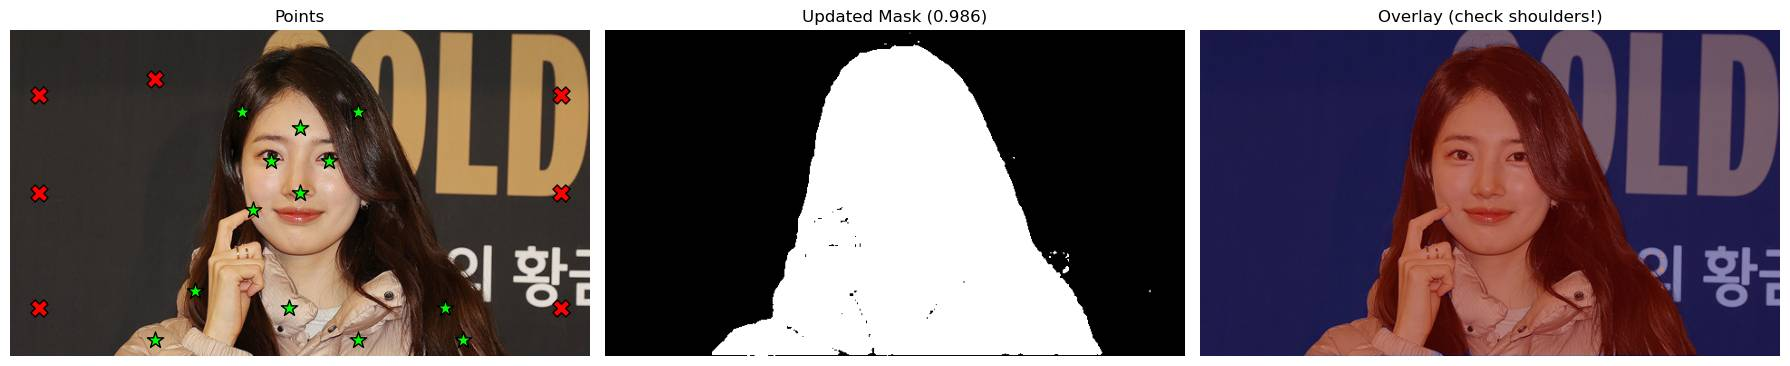

In [36]:
# ============================================================
# SAM 재예측 (점 추가 반영)
# ============================================================
print('🎯 SAM 재예측 중...')
masks, scores, _ = predictor.predict(
    point_coords=all_points,
    point_labels=all_labels,
    multimask_output=True,
)

best_idx = np.argmax(scores)
best_mask = masks[best_idx]
img_mask_sam = (best_mask * 255).astype(np.uint8)

print(f'✅ 점수: {scores[best_idx]:.3f}')

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
axes[0].imshow(person_rgb)
axes[0].scatter(input_point[:, 0], input_point[:, 1], 
                c='lime', s=150, marker='*', edgecolors='black')
axes[0].scatter(bg_points[:, 0], bg_points[:, 1], 
                c='red', s=150, marker='X', edgecolors='black')
axes[0].set_title('Points')
axes[0].axis('off')

axes[1].imshow(img_mask_sam, cmap='gray')
axes[1].set_title(f'Updated Mask ({scores[best_idx]:.3f})')
axes[1].axis('off')

axes[2].imshow(person_rgb)
axes[2].imshow(img_mask_sam, alpha=0.4, cmap='jet')
axes[2].set_title('Overlay (check shoulders!)')
axes[2].axis('off')
plt.tight_layout()
plt.show()

/tmp/ipykernel_1066/1170845789.py:35: UserWarning: Glyph 10024 (\N{SPARKLES}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


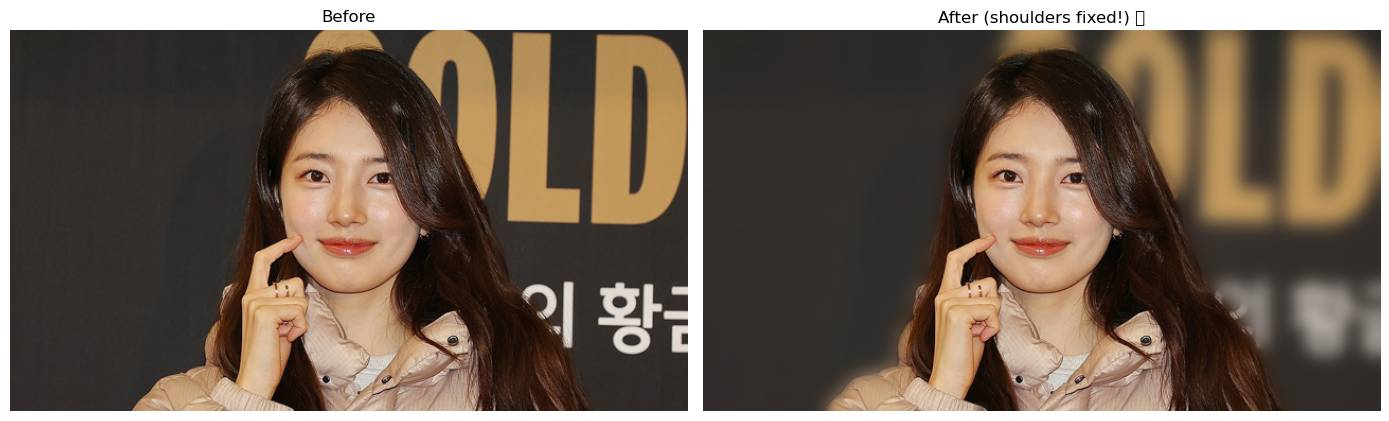

In [34]:
# ============================================================
# 아웃포커싱 재적용
# ============================================================

# 노이즈 제거
kernel = np.ones((5, 5), np.uint8)
mask_closed = cv2.morphologyEx(img_mask_sam, cv2.MORPH_CLOSE, kernel)

num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(mask_closed)
if num_labels > 1:
    largest = 1 + np.argmax(stats[1:, cv2.CC_STAT_AREA])
    mask_clean = np.where(labels == largest, 255, 0).astype(np.uint8)
else:
    mask_clean = mask_closed

# 페더링
mask_soft = cv2.GaussianBlur(mask_clean, (21, 21), 0)
mask_soft_norm = mask_soft.astype(np.float32) / 255.0

# 아웃포커싱
blur_strength = 51
background_blurred = cv2.GaussianBlur(person_rgb, (blur_strength, blur_strength), 0)
mask_3ch = np.stack([mask_soft_norm, mask_soft_norm, mask_soft_norm], axis=2)
result = (person_rgb * mask_3ch + 
          background_blurred * (1 - mask_3ch)).astype(np.uint8)

# Before / After
fig, axes = plt.subplots(1, 2, figsize=(14, 7))
axes[0].imshow(person_rgb)
axes[0].set_title('Before')
axes[0].axis('off')
axes[1].imshow(result)
axes[1].set_title('After (shoulders fixed!) ✨')
axes[1].axis('off')
plt.tight_layout()
plt.show()

# 3. 동물사진 아웃포커싱해보자

## DeepLab의 Pascal VOC클래스에 나무늘보, 사자, 북극곰, 고릴라가 없어서 아무것도 못할거라고 한다. 과연?

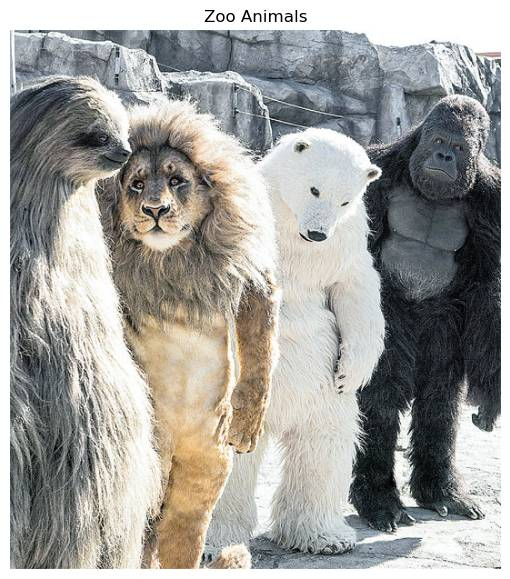

In [43]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))
plt.imshow(zoo_rgb)
plt.title('Zoo Animals')
plt.axis('off')
plt.show()

In [40]:
# ============================================================
# DeepLab으로 동물원 사진 분석 (실험!)
# ============================================================
import torch
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

# DeepLab 모델 확인 (없으면 재로드)
if 'model' not in dir():
    from torchvision.models.segmentation import deeplabv3_resnet101
    import torchvision.transforms as T
    
    print('🔄 DeepLab 로드 중...')
    model = deeplabv3_resnet101(pretrained=True).eval()
    transform = T.Compose([
        T.ToPILImage(),
        T.Resize((520, 520)),
        T.ToTensor(),
    ])

# 동물원 사진 로드
home_dir = os.getenv('HOME')
zoo_path = os.path.join(home_dir, 'work/zoo.jpg')
zoo_bgr = cv2.imread(zoo_path)
zoo_rgb = cv2.cvtColor(zoo_bgr, cv2.COLOR_BGR2RGB)

print(f'이미지 크기: {zoo_rgb.shape}')

# DeepLab 실행
print('🔍 DeepLab 분석 중...')
input_tensor = transform(zoo_rgb).unsqueeze(0)
with torch.no_grad():
    output = model(input_tensor)["out"][0]
    predictions = output.argmax(0).byte().cpu().numpy()

# 원본 크기로 리사이즈
h, w = zoo_rgb.shape[:2]
predictions_resized = cv2.resize(
    predictions, (w, h),
    interpolation=cv2.INTER_NEAREST
)

# 검출된 클래스 확인
unique_classes = np.unique(predictions_resized)

# 클래스 이름 매핑
class_names = {
    0: '배경', 1: '비행기', 2: '자전거', 3: '새', 4: '보트',
    5: '병', 6: '버스', 7: '자동차', 8: '고양이', 9: '의자',
    10: '소', 11: '식탁', 12: '강아지', 13: '말', 14: '오토바이',
    15: '사람', 16: '화분', 17: '양', 18: '소파', 19: '기차', 20: 'TV'
}

print(f'\n🎯 검출된 클래스:')
for cls in unique_classes:
    count = np.sum(predictions_resized == cls)
    percentage = count / (h*w) * 100
    name = class_names.get(cls, f'Unknown-{cls}')
    print(f'  - Class {cls} ({name}): {count:,}픽셀 ({percentage:.1f}%)')

이미지 크기: (593, 540, 3)
🔍 DeepLab 분석 중...

🎯 검출된 클래스:
  - Class 0 (배경): 320,220픽셀 (100.0%)


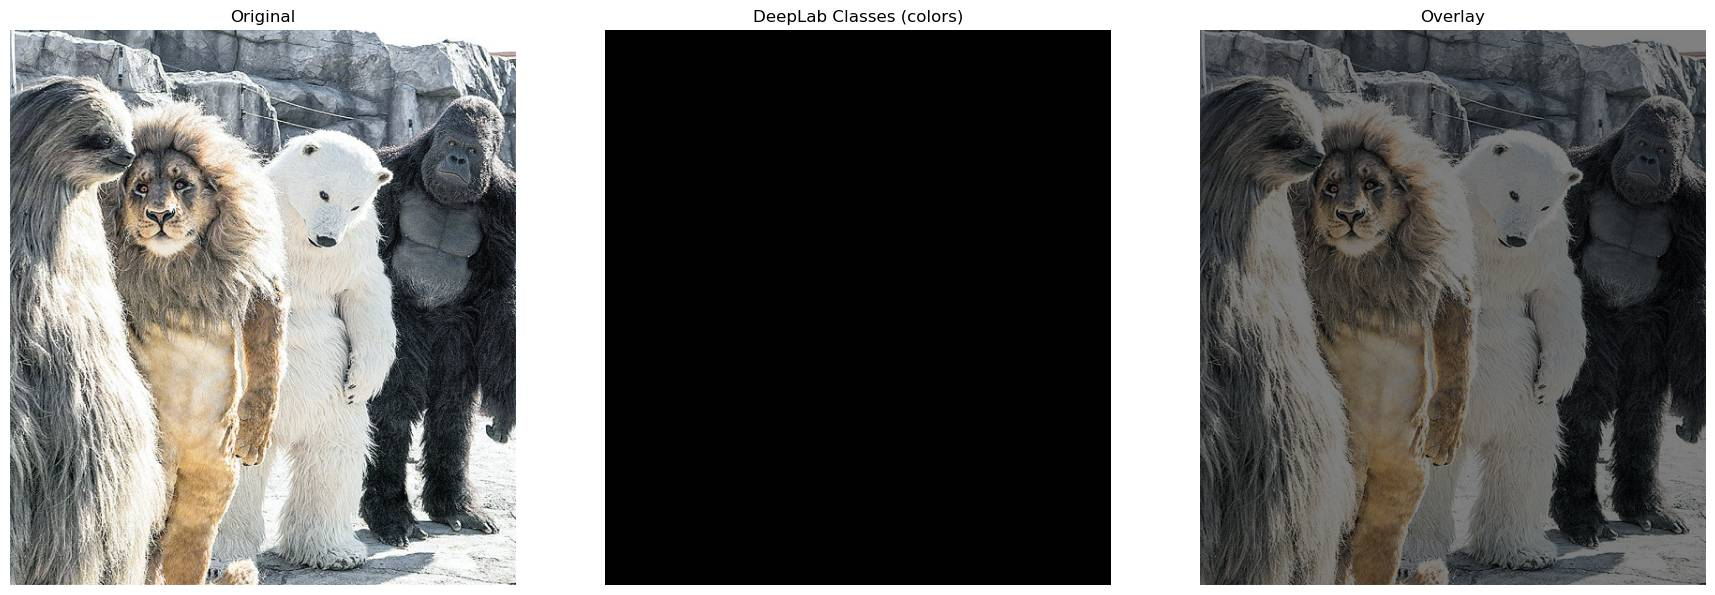


📖 이 사진에서 DeepLab이 본 것:


In [41]:
# ============================================================
# 각 클래스를 다른 색으로 표시
# ============================================================

# 21개 클래스별 색상 (Pascal VOC 표준 팔레트)
VOC_COLORS = np.array([
    [0, 0, 0],          # 0: 배경 (검정)
    [128, 0, 0],        # 1: 비행기
    [0, 128, 0],        # 2: 자전거
    [128, 128, 0],      # 3: 새
    [0, 0, 128],        # 4: 보트
    [128, 0, 128],      # 5: 병
    [0, 128, 128],      # 6: 버스
    [128, 128, 128],    # 7: 자동차
    [64, 0, 0],         # 8: 고양이 🐱
    [192, 0, 0],        # 9: 의자
    [64, 128, 0],       # 10: 소 🐄
    [192, 128, 0],      # 11: 식탁
    [64, 0, 128],       # 12: 강아지 🐕
    [192, 0, 128],      # 13: 말 🐎
    [64, 128, 128],     # 14: 오토바이
    [192, 128, 128],    # 15: 사람 👤
    [0, 64, 0],         # 16: 화분
    [128, 64, 0],       # 17: 양 🐑
    [0, 192, 0],        # 18: 소파
    [128, 192, 0],      # 19: 기차
    [0, 64, 128],       # 20: TV
])

# 색상 마스크 생성
color_mask = np.zeros((h, w, 3), dtype=np.uint8)
for cls in unique_classes:
    color_mask[predictions_resized == cls] = VOC_COLORS[cls]

# 3개 이미지 나란히
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(zoo_rgb)
axes[0].set_title('Original')
axes[0].axis('off')

axes[1].imshow(color_mask)
axes[1].set_title('DeepLab Classes (colors)')
axes[1].axis('off')

axes[2].imshow(zoo_rgb)
axes[2].imshow(color_mask, alpha=0.5)
axes[2].set_title('Overlay')
axes[2].axis('off')

plt.tight_layout()
plt.show()

# 범례 출력
print('\n📖 이 사진에서 DeepLab이 본 것:')
for cls in unique_classes:
    if cls == 0:
        continue
    name = class_names.get(cls, f'Unknown-{cls}')
    color = VOC_COLORS[cls]
    print(f'  ● Class {cls} ({name}) - RGB{tuple(color)}')

In [42]:
# ============================================================
# 각 검출된 클래스를 개별적으로 확인
# ============================================================

# 배경(0) 제외하고 검출된 클래스들
detected = [c for c in unique_classes if c != 0]

if len(detected) == 0:
    print('❌ 어떤 클래스도 검출 안됨 (모두 배경으로 분류)')
else:
    fig, axes = plt.subplots(1, len(detected) + 1, figsize=(5*(len(detected)+1), 5))
    
    if len(detected) == 1:
        axes = [axes[0], axes[1]]
    
    # 원본
    axes[0].imshow(zoo_rgb)
    axes[0].set_title('Original')
    axes[0].axis('off')
    
    # 각 클래스 마스크
    for i, cls in enumerate(detected):
        mask = (predictions_resized == cls).astype(np.uint8) * 255
        name = class_names.get(cls, f'Unknown')
        
        # 원본 위에 해당 클래스만 선명하게 표시
        mask_3ch = np.stack([mask/255]*3, axis=2)
        highlighted = (zoo_rgb * mask_3ch + zoo_rgb * 0.2 * (1-mask_3ch)).astype(np.uint8)
        
        axes[i+1].imshow(highlighted)
        axes[i+1].set_title(f'Class {cls}: {name}')
        axes[i+1].axis('off')
    
    plt.tight_layout()
    plt.show()

❌ 어떤 클래스도 검출 안됨 (모두 배경으로 분류)


## DeepLab은 학습한것만 인식을 해서 야생 동물 대부분 인식 불가!   
## 다시 SAM으로!

🔍 이미지 분석 중...
✅ 완료! 이미지 크기: (593, 540, 3)


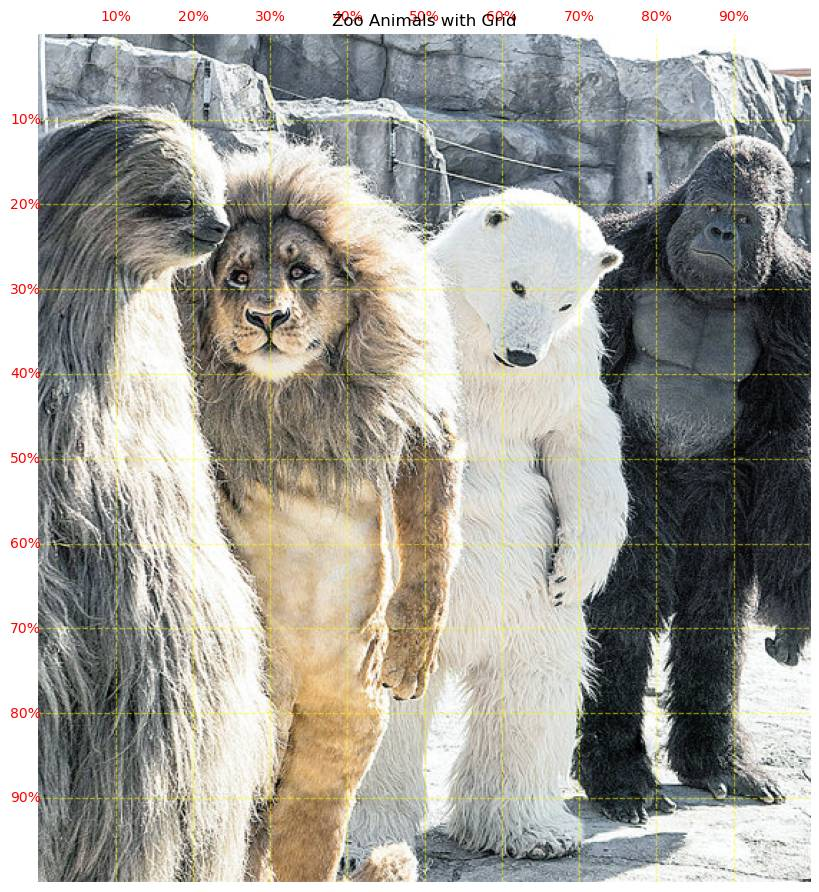

이미지 크기: 540 x 593


In [44]:
# ============================================================
# SAM에 동물원 이미지 등록
# ============================================================
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

home_dir = os.getenv('HOME')

# 이미지 로드
zoo_path = os.path.join(home_dir, 'work/zoo.jpg')
zoo_bgr = cv2.imread(zoo_path)
zoo_rgb = cv2.cvtColor(zoo_bgr, cv2.COLOR_BGR2RGB)

# SAM에 이미지 등록
print('🔍 이미지 분석 중...')
predictor.set_image(zoo_rgb)
print(f'✅ 완료! 이미지 크기: {zoo_rgb.shape}')

# 격자와 함께 표시 (좌표 찾기용)
h, w = zoo_rgb.shape[:2]

plt.figure(figsize=(14, 9))
plt.imshow(zoo_rgb)

# 가로/세로 10% 간격 격자
for i in range(1, 10):
    plt.axhline(y=h*i/10, color='yellow', linestyle='--', linewidth=1, alpha=0.5)
    plt.axvline(x=w*i/10, color='yellow', linestyle='--', linewidth=1, alpha=0.5)
    plt.text(-20, h*i/10, f'{i*10}%', color='red', fontsize=10, va='center')
    plt.text(w*i/10, -10, f'{i*10}%', color='red', fontsize=10, ha='center')

plt.title('Zoo Animals with Grid')
plt.axis('off')
plt.tight_layout()
plt.show()

print(f'이미지 크기: {w} x {h}')

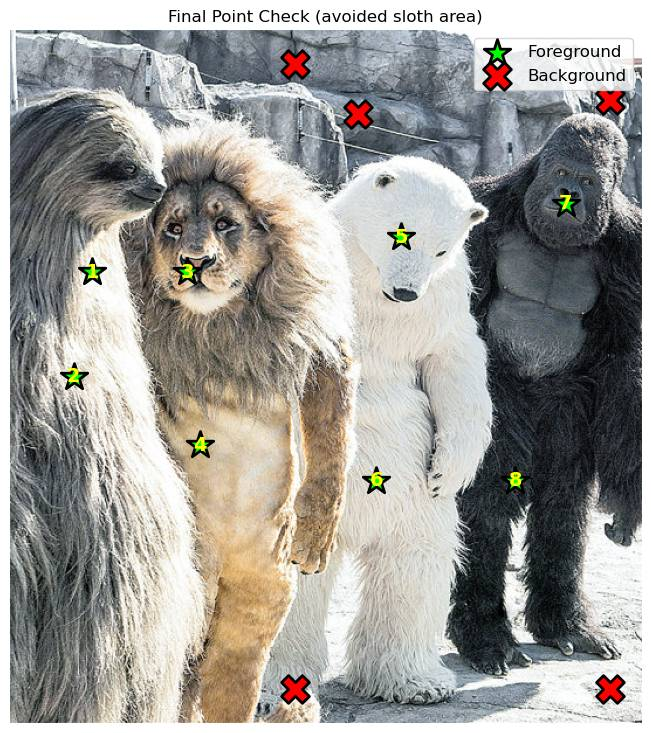

In [57]:
# ============================================================
# 배경 점 위치 재조정 (나무늘보 피하기)
# ============================================================
h, w = zoo_rgb.shape[:2]

# 🟢 전경 점 (이전 그대로)
input_point = np.array([
    # 🦥 나무늘보
    [w * 0.13, h * 0.35],    # 1
    [w * 0.10, h * 0.50],    # 2
    
    # 🦁 사자
    [w * 0.28, h * 0.35],    # 3
    [w * 0.30, h * 0.60],    # 4
    
    # 🐻‍❄️ 북극곰
    [w * 0.62, h * 0.30],    # 5
    [w * 0.58, h * 0.65],    # 6
    
    # 🦍 고릴라
    [w * 0.88, h * 0.25],    # 7
    [w * 0.80, h * 0.65],    # 8
]).astype(int)

# 🔴 배경 점 (수정!)
bg_points = np.array([
    # 위쪽 바위 - 나무늘보 없는 오른쪽
    [w * 0.45, h * 0.05],
    [w * 0.55, h * 0.12],
    [w * 0.95, h * 0.10],
    
    # 아래쪽 - 나무늘보 없는 중앙/오른쪽
    [w * 0.45, h * 0.95],
    [w * 0.95, h * 0.95],
]).astype(int)

all_points = np.vstack([input_point, bg_points])
all_labels = np.array([1]*len(input_point) + [0]*len(bg_points))

# 점 위치 확인
plt.figure(figsize=(14, 9))
plt.imshow(zoo_rgb)
plt.scatter(input_point[:, 0], input_point[:, 1],
            c='lime', s=400, marker='*', 
            edgecolors='black', linewidths=2, label='Foreground')
plt.scatter(bg_points[:, 0], bg_points[:, 1],
            c='red', s=400, marker='X',
            edgecolors='black', linewidths=2, label='Background')

for i, pt in enumerate(input_point):
    plt.annotate(f'{i+1}', pt, color='yellow', fontsize=14,
                 fontweight='bold', ha='center', va='center')

plt.title('Final Point Check (avoided sloth area)')
plt.legend(fontsize=12, loc='upper right')
plt.axis('off')
plt.show()

🎯 SAM 예측 중...
✅ 점수: 0.964


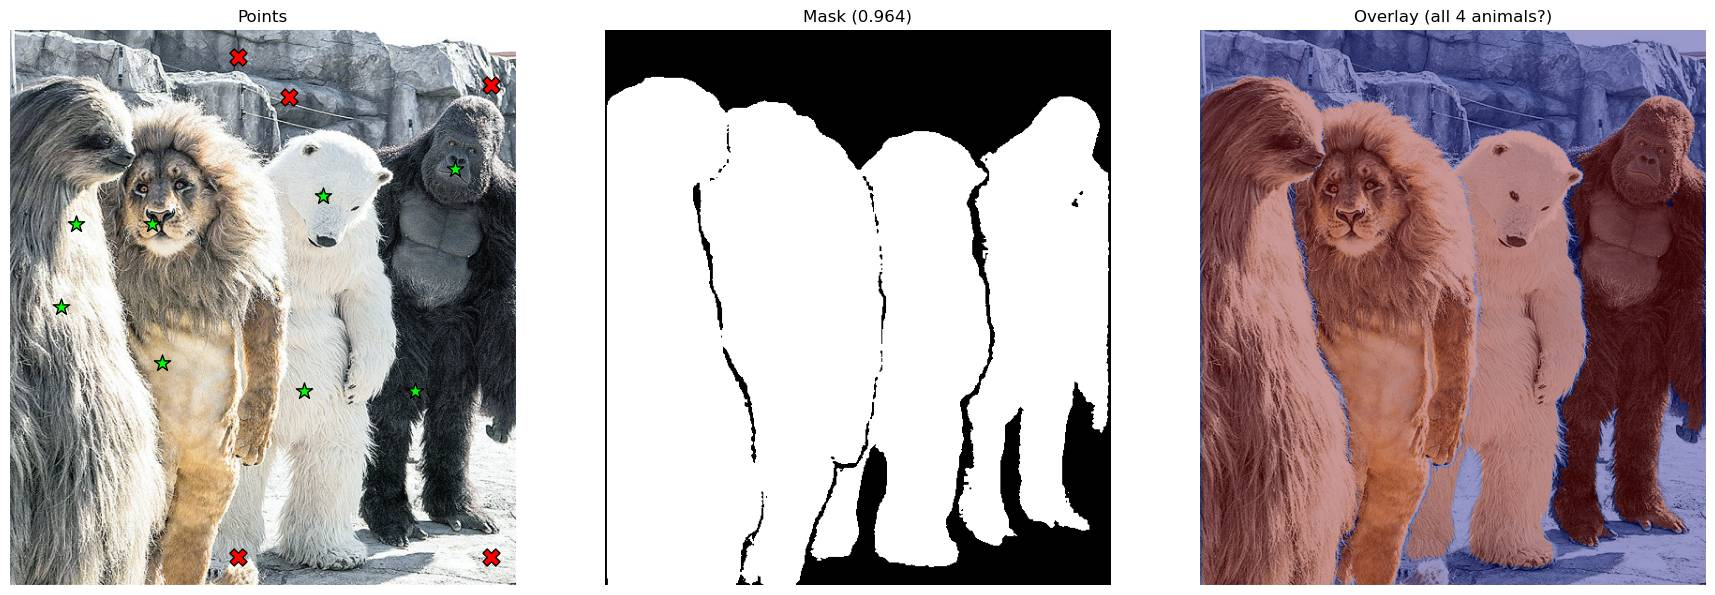

In [58]:
# SAM 예측
print('🎯 SAM 예측 중...')
masks, scores, _ = predictor.predict(
    point_coords=all_points,
    point_labels=all_labels,
    multimask_output=True,
)

best_idx = np.argmax(scores)
best_mask = masks[best_idx]
img_mask_sam = (best_mask * 255).astype(np.uint8)

print(f'✅ 점수: {scores[best_idx]:.3f}')

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
axes[0].imshow(zoo_rgb)
axes[0].scatter(input_point[:, 0], input_point[:, 1],
                c='lime', s=150, marker='*', edgecolors='black')
axes[0].scatter(bg_points[:, 0], bg_points[:, 1],
                c='red', s=150, marker='X', edgecolors='black')
axes[0].set_title('Points')
axes[0].axis('off')

axes[1].imshow(img_mask_sam, cmap='gray')
axes[1].set_title(f'Mask ({scores[best_idx]:.3f})')
axes[1].axis('off')

axes[2].imshow(zoo_rgb)
axes[2].imshow(img_mask_sam, alpha=0.4, cmap='jet')
axes[2].set_title('Overlay (all 4 animals?)')
axes[2].axis('off')
plt.tight_layout()
plt.show()

/tmp/ipykernel_1066/1154314129.py:33: UserWarning: Glyph 10024 (\N{SPARKLES}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


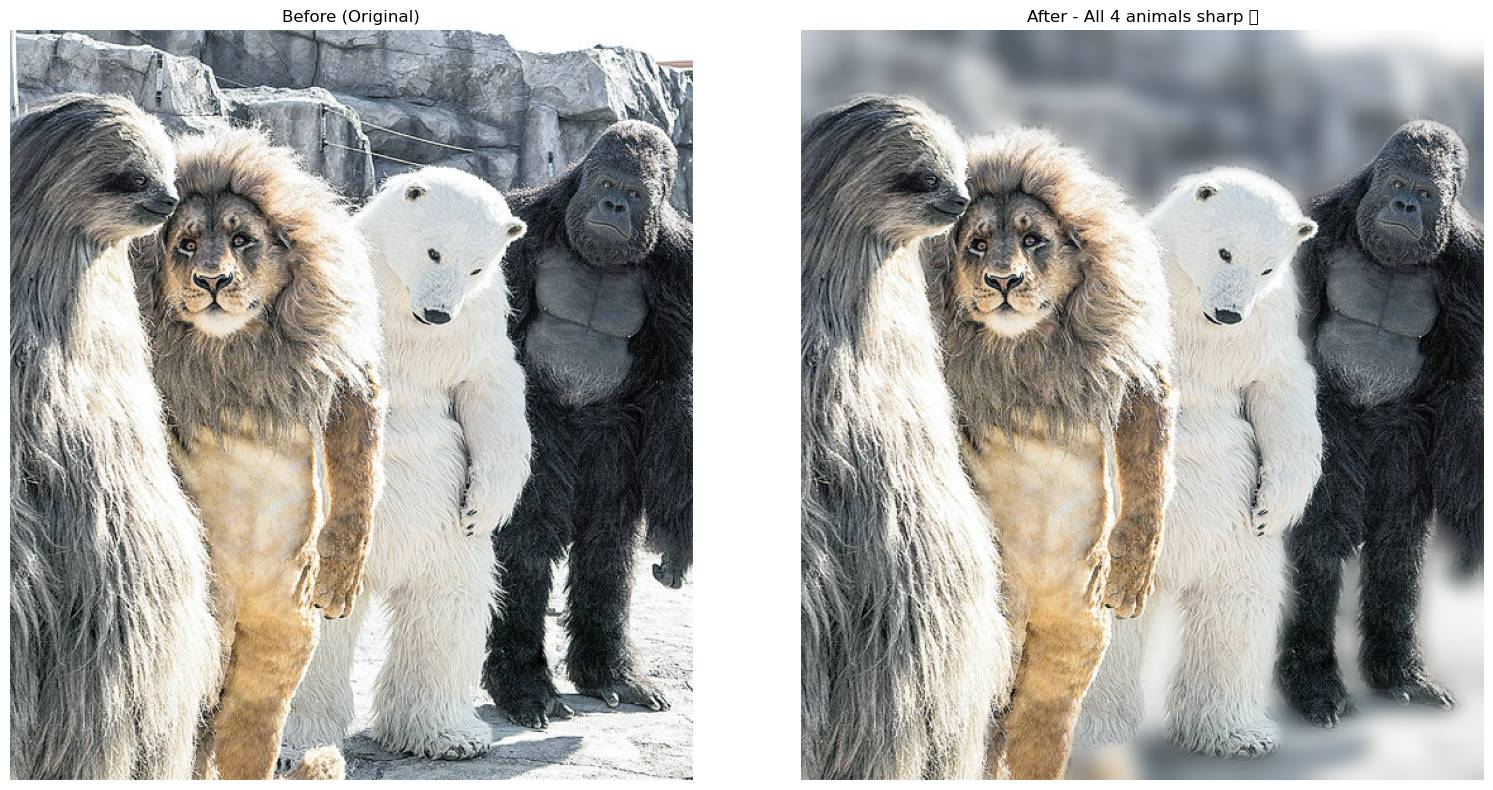

In [59]:
# ============================================================
# 최종 아웃포커싱 - 동물들은 선명, 바위 배경 블러
# ============================================================

# 1. 노이즈 제거
kernel = np.ones((5, 5), np.uint8)
mask_closed = cv2.morphologyEx(img_mask_sam, cv2.MORPH_CLOSE, kernel)

# 2. 경계 부드럽게 (페더링)
mask_soft = cv2.GaussianBlur(mask_closed, (21, 21), 0)
mask_soft_norm = mask_soft.astype(np.float32) / 255.0

# 3. 배경 블러 처리
blur_strength = 51    # ⭐ 21 약함, 51 보통, 99 강함
background_blurred = cv2.GaussianBlur(zoo_rgb, (blur_strength, blur_strength), 0)

# 4. 알파 블렌딩
mask_3ch = np.stack([mask_soft_norm]*3, axis=2)
result = (zoo_rgb * mask_3ch + 
          background_blurred * (1 - mask_3ch)).astype(np.uint8)

# 5. Before / After 비교
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

axes[0].imshow(zoo_rgb)
axes[0].set_title('Before (Original)')
axes[0].axis('off')

axes[1].imshow(result)
axes[1].set_title('After - All 4 animals sharp ✨')
axes[1].axis('off')

plt.tight_layout()
plt.show()

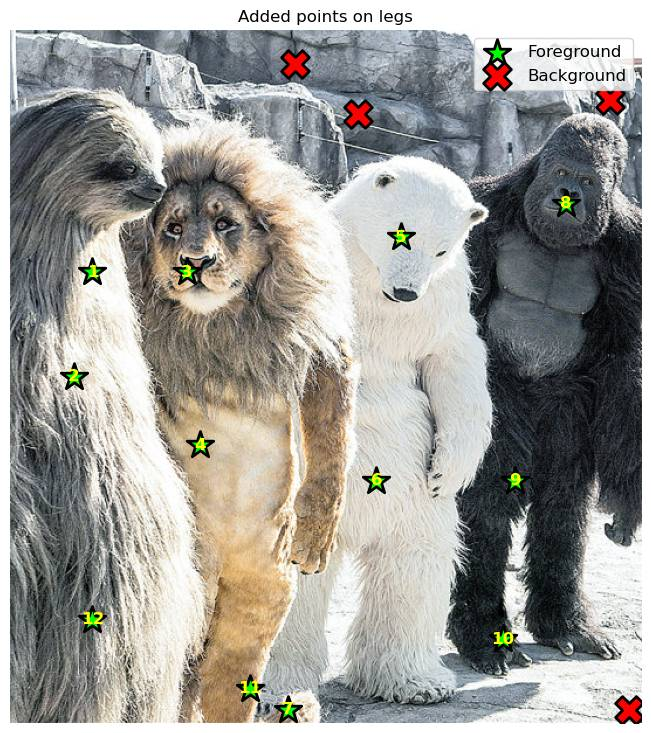

In [74]:
# ============================================================
# 북극곰, 고릴라 다리에 점 추가
# ============================================================
h, w = zoo_rgb.shape[:2]

# 🟢 전경 점 (다리 점 추가!)
input_point = np.array([
    # 🦥 나무늘보
    [w * 0.13, h * 0.35],    # 1. 나무늘보
    [w * 0.10, h * 0.50],    # 2. 나무늘보
    
    # 🦁 사자
    [w * 0.28, h * 0.35],    # 3. 사자
    [w * 0.30, h * 0.60],    # 4. 사자
    
    # 🐻‍❄️ 북극곰
    [w * 0.62, h * 0.30],    # 5. 북극곰 얼굴
    [w * 0.58, h * 0.65],    # 6. 북극곰 몸통
    [w * 0.44, h * 0.98],    # 9. ⭐ 북극곰 다리 아래 (추가!)
    
    # 🦍 고릴라
    [w * 0.88, h * 0.25],    # 7. 고릴라 얼굴
    [w * 0.80, h * 0.65],    # 8. 고릴라 몸통
    [w * 0.78, h * 0.88],    # 10. ⭐ 고릴라 다리 아래 (추가!)
    
    # 🦁 사자 발도 혹시 몰라 추가
    [w * 0.38, h * 0.95],    # 11. ⭐ 사자 다리 아래 (추가!)
    
    # 🦥 나무늘보 아래도 추가
    [w * 0.13, h * 0.85],    # 12. ⭐ 나무늘보 아래 (추가!)
]).astype(int)

# 🔴 배경 점 (수정 - 동물 다리 방해 안 하도록)
bg_points = np.array([
    # 위쪽 바위
    [w * 0.45, h * 0.05],
    [w * 0.55, h * 0.12],
    [w * 0.95, h * 0.10],
    
    # ⭐ 아래쪽 배경은 더 아래로 (동물 발끝 완전히 피해서)
    [w * 0.98, h * 0.98],    # 맨 오른쪽 아래 구석
]).astype(int)

all_points = np.vstack([input_point, bg_points])
all_labels = np.array([1]*len(input_point) + [0]*len(bg_points))

# 점 위치 확인
plt.figure(figsize=(14, 9))
plt.imshow(zoo_rgb)
plt.scatter(input_point[:, 0], input_point[:, 1],
            c='lime', s=400, marker='*', 
            edgecolors='black', linewidths=2, label='Foreground')
plt.scatter(bg_points[:, 0], bg_points[:, 1],
            c='red', s=400, marker='X',
            edgecolors='black', linewidths=2, label='Background')

for i, pt in enumerate(input_point):
    plt.annotate(f'{i+1}', pt, color='yellow', fontsize=12,
                 fontweight='bold', ha='center', va='center')

plt.title('Added points on legs')
plt.legend(fontsize=12, loc='upper right')
plt.axis('off')
plt.show()

🎯 SAM 예측 중...
✅ 점수: 0.969


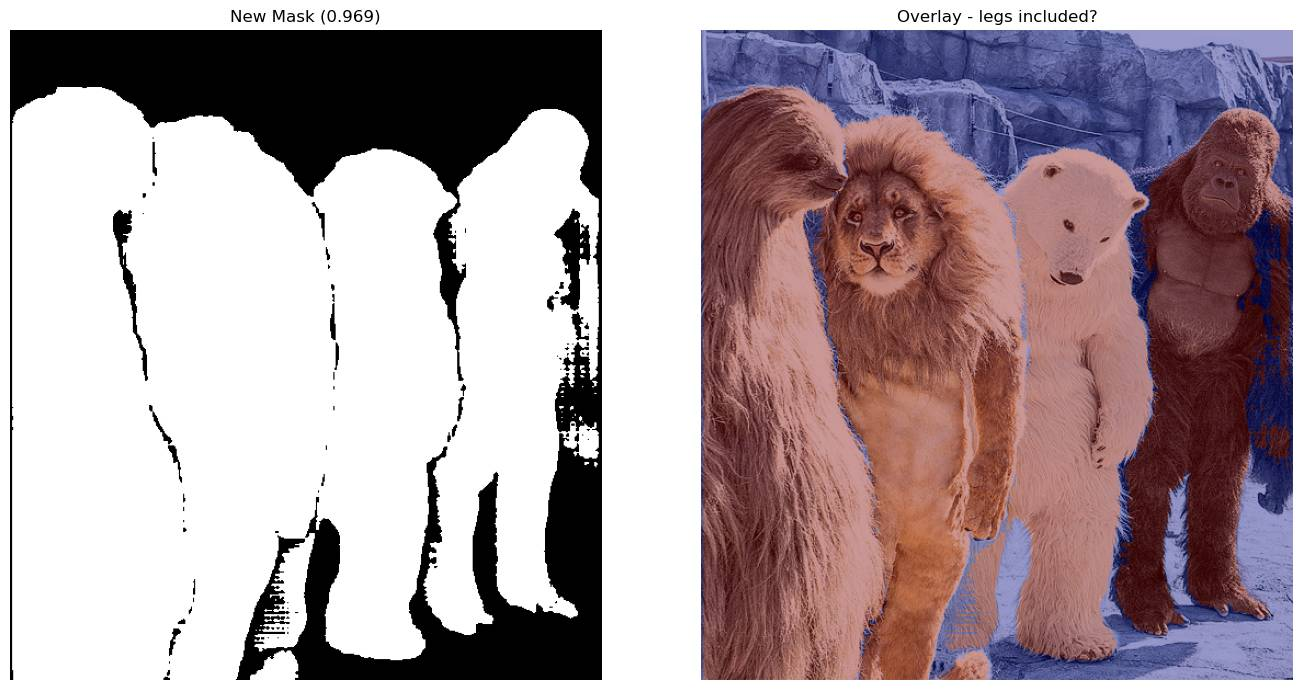

In [75]:
# SAM 예측
print('🎯 SAM 예측 중...')
masks, scores, _ = predictor.predict(
    point_coords=all_points,
    point_labels=all_labels,
    multimask_output=True,
)

best_idx = np.argmax(scores)
best_mask = masks[best_idx]
img_mask_sam = (best_mask * 255).astype(np.uint8)

print(f'✅ 점수: {scores[best_idx]:.3f}')

# 마스크 확인
fig, axes = plt.subplots(1, 2, figsize=(14, 7))
axes[0].imshow(img_mask_sam, cmap='gray')
axes[0].set_title(f'New Mask ({scores[best_idx]:.3f})')
axes[0].axis('off')

axes[1].imshow(zoo_rgb)
axes[1].imshow(img_mask_sam, alpha=0.4, cmap='jet')
axes[1].set_title('Overlay - legs included?')
axes[1].axis('off')
plt.tight_layout()
plt.show()

/tmp/ipykernel_1066/1853244161.py:21: UserWarning: Glyph 10024 (\N{SPARKLES}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


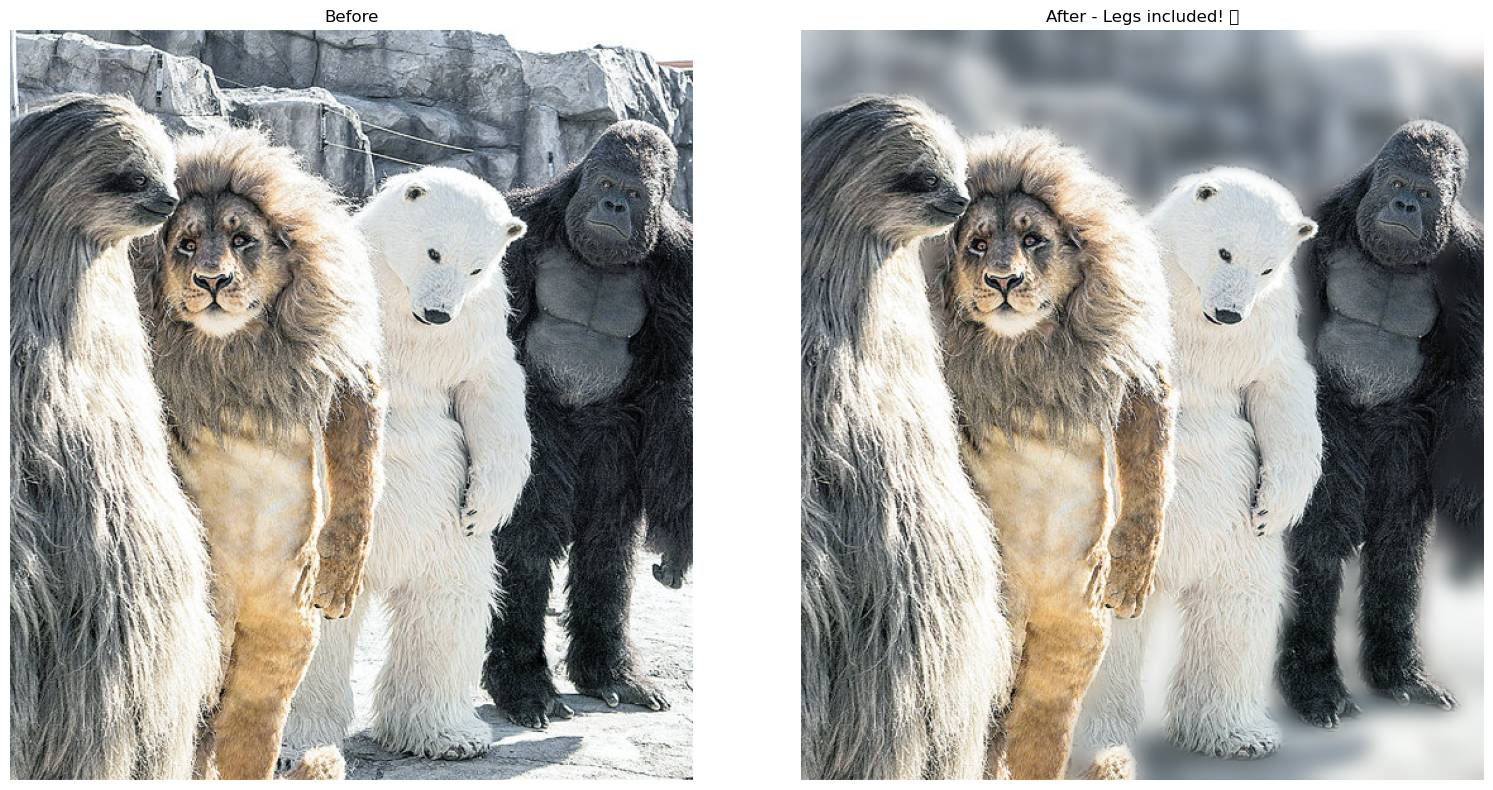

In [76]:
# 아웃포커싱 (이전과 동일)
kernel = np.ones((5, 5), np.uint8)
mask_closed = cv2.morphologyEx(img_mask_sam, cv2.MORPH_CLOSE, kernel)
mask_soft = cv2.GaussianBlur(mask_closed, (21, 21), 0)
mask_soft_norm = mask_soft.astype(np.float32) / 255.0

blur_strength = 51
background_blurred = cv2.GaussianBlur(zoo_rgb, (blur_strength, blur_strength), 0)

mask_3ch = np.stack([mask_soft_norm]*3, axis=2)
result = (zoo_rgb * mask_3ch + 
          background_blurred * (1 - mask_3ch)).astype(np.uint8)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))
axes[0].imshow(zoo_rgb)
axes[0].set_title('Before')
axes[0].axis('off')
axes[1].imshow(result)
axes[1].set_title('After - Legs included! ✨')
axes[1].axis('off')
plt.tight_layout()
plt.show()


## 🔬 시행착오와 학습

### 1차 시도: DeepLab v3

- **장점**: 빠르고 자동으로 객체 클래스 인식
- **한계**: 
  - 얇은 꼬리 같은 디테일을 놓침
  - 520x520 입력 크기 제한으로 경계가 거칠어짐
  - Pascal VOC 21개 클래스 외의 객체는 전혀 인식하지 못함

특히 동물원 사진(나무늘보, 사자, 북극곰, 고릴라)에서는 **4마리 모두 배경으로 분류**하는 
충격적인 결과를 보여, 학습 데이터에 없는 객체에 대한 모델의 무력함을 확인했습니다.

### 2차 시도: 마스크 팽창(Dilation)

꼬리 잘림 문제를 해결하기 위해 마스크를 확장했으나, 
**주변 낙엽까지 "고양이"로 포함되는** 새로운 문제가 발생했습니다.
배경이 복잡할수록 단순한 팽창 연산으로는 한계가 있음을 학습했습니다.

### 3차 시도: GrabCut

색상 분포 기반의 대화형 분할 알고리즘을 시도했지만, 
**낙엽과 고양이 털 색상이 비슷해** 구분에 실패했습니다. 
결과적으로 이미지 전체를 "전경"으로 분류하는 오류가 발생했습니다.

### 4차 시도: SAM (Segment Anything Model) ✅

Meta가 2023년 공개한 최신 모델로, 점(point) 기반으로 사용자가 직접 
전경/배경을 지정할 수 있습니다.
- 클래스에 구애받지 않고 어떤 객체든 분리 가능
- 점을 여러 개 찍어 정교한 제어 가능
- **점수 0.96 이상의 높은 정확도** 달성

동물원 사진에서도 4마리 동물을 모두 정확하게 분리하여 
DeepLab의 한계를 완벽히 극복했습니다.

## 💡 핵심 학습 내용

### 기술적 배움

- **BGR ↔ RGB 변환의 중요성**: OpenCV와 matplotlib의 색공간 차이
- **알파 블렌딩**: 0~1 사이 값으로 부드러운 경계 만들기
- **가우시안 블러**: 이진 마스크를 부드러운 마스크로 변환
- **모폴로지 연산**: CLOSE로 구멍 메우기, Connected Components로 노이즈 제거
- **좌표 정규화**: `w * 0.5` 같은 비율 기반 좌표로 이미지 크기 무관하게 점 지정

### 실무적 교훈

- **세그멘테이션의 한계**: 어떤 모델도 완벽하지 않으며, 
  데이터와 상황에 맞는 도구 선택이 중요
- **디테일 문제**: 얇은 구조(꼬리, 다리, 머리카락)는 별도 점 지정 필요
- **점 배치의 중요성**: 배경 점이 전경에 겹치면 결과 망가짐
- **반복 개선**: 한 번에 완벽한 결과는 없고, 시행착오가 자연스러움

## 🎨 최종 결과

### 크로마키 합성 (고양이 → 사막)
- SAM으로 정교한 마스크 생성 후 배경 교체
- 그림자 추가로 공중 부양 느낌 해소
- 색감 조정으로 사막 톤과 자연스럽게 매칭

### 인물 아웃포커싱 (수지 사진)
- SAM으로 얼굴, 머리카락, 옷, 손까지 정확히 분리
- 경계 페더링으로 DSLR 인물 모드 같은 자연스러운 효과

### 동물 아웃포커싱 (동물원 4마리)
- DeepLab이 실패한 장면에서 SAM이 점수 0.96으로 성공
- 네 마리 동물 모두 선명하게 유지

## 🚀 한계와 개선 방향

### 현재의 한계

- **수동 점 지정 필요**: SAM은 사용자가 점을 찍어야 함
- **얇은 구조 취약**: 동물 다리, 꼬리 등에 점을 안 찍으면 놓침
- **복잡한 배경**: 피사체와 색상이 비슷한 배경에서 경계 애매
- **실시간 처리 어려움**: SAM은 한 장 처리에도 시간 소요


## 📚 오늘 배운 것 요약

하나의 문제를 해결하기 위해 여러 접근 방법을 시도하고, 
각 방법의 장단점을 직접 체험하며 모델의 한계를 이해함.
정말 노가다였음.


특히 DeepLab이 동물원 사진에서 완전히 실패하는 것을 눈으로 확인하며, 
"모델은 학습한 것만 인식한다"는 당연한 사실을 체감할 수 있었음.
